# Lưu trus: khách sạn lớn, nhà nghỉ, resort

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

EDA_DIR = ROOT / "data/qa/eda"
SCOPE = "7tinh"

poi = pq.read_table(EDA_DIR / f"poi_extended_{SCOPE}_con_lai.parquet").to_pandas()
poi["uid"] = poi["osm_type"].astype(str) + ":" + poi["osm_id"].astype(str)


def parse_tags(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return {}
    return {}


# Parse MỘT lần — bài học từ lớp chung cư: hai chỗ parse bằng hai hàm là hai nguồn sự thật.
poi["tags_dict"] = poi["tags"].map(parse_tags)


def strip_accents(s: str) -> str:
    """Hạ chữ + bỏ dấu tiếng Việt (đ/Đ xử lý riêng vì NFD không tách được)."""
    s = unicodedata.normalize("NFD", str(s)).replace("đ", "d").replace("Đ", "D")
    return re.sub(r"[̀-ͯ]", "", s).lower()


def tag(key):
    """Giá trị tag đã HẠ CHỮ. Bắt buộc: dữ liệu có `tourism=Villa` viết hoa —
    khớp thẳng vào danh sách chữ thường sẽ trượt im lặng."""
    return poi["tags_dict"].map(lambda t, k=key: str(t[k]).lower() if k in t else None)


print(f"bộ còn lại: {len(poi):,} dòng | node {(~poi['is_area']).sum():,} ({(~poi['is_area']).mean():.0%})")
print(poi["province_name"].value_counts().to_string())

bộ còn lại: 183,896 dòng | node 110,930 (60%)
province_name
Thành phố Hồ Chí Minh    58358
Thành phố Hà Nội         53956
Thành phố Đà Nẵng        21455
Tỉnh Đồng Nai            19336
Thành phố Hải Phòng      12006
Thành phố Cần Thơ        11293
Tỉnh Quảng Ninh           7492


## Bước 1: filter MỎNG, ưu tiên recall

Mục tiêu: **không bỏ sót** một cơ sở lưu trú nào. Nhiễu chấp nhận, lọc ở bước sau.

Bốn nhánh, mỗi nhánh một loại bằng chứng độc lập:

- A tag chức năng
- B regex tên
- C branding, operator
- D stars

In [2]:
LODGING_VALUES_CORE = {"hotel", "hostel", "motel", "guest_house", "resort", "chalet", "love_hotel"}

td = poi["tags_dict"]
poi["tourism"] = tag("tourism")
poi["building"] = tag("building")
poi["leisure"] = tag("leisure")
poi["amenity"] = tag("amenity")
poi["stars"] = td.map(lambda t: t.get("stars"))
poi["construction"] = tag("construction")
# tag VÒNG ĐỜI (`disused:tourism=hotel`, `was:tourism=hotel`): khách sạn đã đóng cửa hoặc
# đổi công năng. Bước 1 vẫn phải tuyển — giữ hay bỏ là quyết định của bước sau.
poi["lifecycle_lodging"] = td.map(
    lambda t: any(
        ":" in k and k.split(":")[-1] == "tourism" and str(v).lower() in LODGING_VALUES_CORE
        for k, v in t.items()
    )
)
poi["rooms"] = pd.to_numeric(td.map(lambda t: t.get("rooms")), errors="coerce")
poi["operator"] = td.map(lambda t: t.get("operator"))
poi["brand"] = td.map(lambda t: t.get("brand"))

# gộp mọi biến thể tên như lớp trước
alt_names = td.map(
    lambda t: " ".join(v for v in (t.get("name:vi"), t.get("name:en"), t.get("alt_name"), t.get("old_name")) if v)
)
poi["name_norm"] = (poi["name"].fillna("").map(strip_accents) + " " + alt_names.map(strip_accents)).str.strip()
name_norm = poi["name_norm"]

# --- A. tag chức năng ---
LODGING_TAG = (
    poi["tourism"].isin(
        ["hotel", "hostel", "motel", "guest_house", "apartment", "chalet", "resort",
         "villa", "alpine_hut", "wilderness_hut", "camp_site", "caravan_site", "love_hotel"]
    )
    | poi["building"].isin(["hotel", "guest_house"])
    | poi["leisure"].isin(["resort", "beach_resort"])
    | poi["amenity"].isin(["love_hotel", "hostel", "motel_month"])
    # KHÁCH SẠN ĐANG XÂY — đúng bài học của `construction=residential` ở lớp chung cư:
    # bước 1 không đọc key `construction` thì "Wyndham Soleil Danang" biến mất không dấu vết.
    | poi["construction"].isin(["hotel", "hostel", "motel", "guest_house", "resort", "chalet"])
    | poi["lifecycle_lodging"]
)

# --- B. từ khoá tên (đã bỏ dấu) ---
# Nhóm theo HẠNG, vì chính cách gọi là tín hiệu quy mô mạnh nhất mà lớp này có.
LODGING_RX = (
    # hạng khách sạn
    r"khach san|\bks\b|\bhotel\b|\bhotels\b|khach xa"
    # hạng nhà nghỉ / nhà khách
    r"|nha nghi|nha khach|\bmotel\b|quan tro|nghi chan"
    # hạng homestay / hostel / guesthouse
    r"|homestay|home stay|hostel|guest ?house|\binn\b|backpacker"
    # hạng resort / nghỉ dưỡng
    r"|resort|nghi duong|nghi mat|khu du lich|\bkdl\b|bungalow|farmstay|ecolodge|\blodge\b"
    # căn hộ dịch vụ / condotel — vắt giữa lưu trú và nhà ở, tuyển vào để QUYẾT MỘT LẦN ở đây
    r"|condotel|can ho dich vu|serviced apartment|apart ?hotel|hometel"
    # villa / biệt thự cho thuê (khu biệt thự ĐỂ Ở đã bị lớp chung cư bóc đi từ trước)
    r"|\bvillas?\b|biet thu|\bresidence inn\b"
)
LODGING_NAME = name_norm.str.contains(LODGING_RX, regex=True, na=False)

# --- C. brand / operator là CHUỖI KHÁCH SẠN ---
# Neo biên là BẮT BUỘC — đo trên dữ liệu thật: `lotte` khớp 161 dòng mà chỉ 3 có tag lưu trú
# (còn lại là Lotteria, Lotte Department Store); `nesta` khớp "Ci-nesta-r"; `melia` khớp
# "Ca-melia"; `flc` ở 7 tỉnh này chỉ trỏ tới FLC Garden City — một khu NHÀ Ở, nên bỏ hẳn.
HOTEL_CHAIN_RX = (
    r"muong thanh|vinpearl|\bmelia\b|accor|novotel|marriott|sheraton|intercontinental"
    r"|best western|\bibis\b|pullman|sofitel|hilton|hyatt|radisson|wyndham|anantara"
    r"|movenpick|silk path|\ba25\b|\bnesta\b|furama|banyan tree|six senses|amanoi"
    r"|regent|centara|lotte hotel|lotte legend|fusion (?:maia|suites|resort|originals)"
)
# Quét chuỗi khách sạn trên CẢ TÊN, không chỉ brand/operator: thương hiệu xuất hiện trong
# tên POI nhiều hơn hẳn trong tag. "Wyndham Soleil Danang" không có chữ "hotel" nào trong
# tên — chỉ thương hiệu mới nhận ra nó là khách sạn.
chain_text = (
    poi["brand"].fillna("") + " " + poi["operator"].fillna("") + " " + poi["name_norm"]
).map(strip_accents)
LODGING_CHAIN = chain_text.str.contains(HOTEL_CHAIN_RX, regex=True, na=False)

# --- D. tự khai hạng sao ---
LODGING_STARS = poi["stars"].notna()

poi["is_lodging"] = LODGING_TAG | LODGING_NAME | LODGING_CHAIN | LODGING_STARS

for label, m in [("A tag chức năng", LODGING_TAG), ("B tên", LODGING_NAME),
                 ("C brand/operator chuỗi KS", LODGING_CHAIN), ("D stars", LODGING_STARS)]:
    print(f"  {label:28s} {m.sum():6,}")
print(f"  {'HỢP':28s} {poi['is_lodging'].sum():6,} / {len(poi):,} ({poi['is_lodging'].mean():.2%})")

print("\nđóng góp RIÊNG của từng nhánh (dòng chỉ vào được nhờ nhánh đó):")
BR = {"A tag": LODGING_TAG, "B tên": LODGING_NAME, "C chuỗi": LODGING_CHAIN, "D stars": LODGING_STARS}
for label, m in BR.items():
    khac = np.logical_or.reduce([v.values for k, v in BR.items() if k != label])
    chi_minh_no = m & ~khac
    vd = poi.loc[chi_minh_no, "name"].dropna().head(3).tolist()
    print(f"  {label:10s} {chi_minh_no.sum():5,}  {vd}")

  A tag chức năng               5,410
  B tên                         3,040
  C brand/operator chuỗi KS       149
  D stars                         135
  HỢP                           5,698 / 183,896 (3.10%)

đóng góp RIÊNG của từng nhánh (dòng chỉ vào được nhờ nhánh đó):
  A tag      2,556  ['Thành Công', 'My Khanh', 'Thuỳ Dương']
  B tên        244  ['Cạnh ngõ 18 Nguyễn Khoái (Đối diện Vân Đồn Hotel)', '73 Nguyễn Chí Thanh - Đối diện Khách sạn Bảo Sơn', 'Cổng Khu du lịch Chí Linh']
  C chuỗi       25  ['Siêu thị Mường Thanh H1', 'Siêu thị Mường Thanh H2', 'Siêu thị Mường Thanh']
  D stars        9  ['Nhà Hàng Lẩu Cua', 'Thái Hòa Viên', 'Itada']


In [3]:
tuyen = poi[poi["is_lodging"]]
tuyen

,osm_type,osm_id,is_area,lat,lng,area_m2,n_tags,tags,geometry_wkb,name,...,levels,rooms,stars,operator,brand,name_norm,is_housing,tags_dict,lifecycle_lodging,is_lodging
85,node,335641430,False,21.034004,105.847144,NaN,3,"{""addr:city"": ""Hà Nội"", ""name"": ""Khách Sạn Đức...",None,Khách Sạn Đức Thái,...,NaN,NaN,NaN,NaN,NaN,khach san duc thai,False,"{'addr:city': 'Hà Nội', 'name': 'Khách Sạn Đức...",False,True
220,node,411921743,False,10.784146,106.702247,NaN,7,"{""bench"": ""no"", ""bin"": ""no"", ""bus"": ""yes"", ""hi...",None,Khách sạn Sofitel,...,NaN,NaN,NaN,NaN,NaN,khach san sofitel,False,"{'bench': 'no', 'bin': 'no', 'bus': 'yes', 'hi...",False,True
243,node,442031782,False,21.027311,105.843531,NaN,4,"{""addr:city"": ""Hà Nội"", ""addr:country"": ""VN"", ...",None,Khách Sạn Prince,...,NaN,NaN,NaN,NaN,NaN,khach san prince,False,"{'addr:city': 'Hà Nội', 'addr:country': 'VN', ...",False,True
245,node,442033049,False,21.025833,105.846367,NaN,17,"{""addr:city"": ""Hà Nội"", ""addr:country"": ""VN"", ...",None,Somerset Grand Hanoi,...,NaN,NaN,5,NaN,Somerset,somerset grand hanoi,False,"{'addr:city': 'Hà Nội', 'addr:country': 'VN', ...",False,True
261,node,444142872,False,20.861809,106.686282,NaN,3,"{""name"": ""Bach Dang Hotel"", ""name:ja"": ""バクダンホテ...",None,Bach Dang Hotel,...,NaN,NaN,NaN,NaN,NaN,bach dang hotel,False,"{'name': 'Bach Dang Hotel', 'name:ja': 'バクダンホテ...",False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183734,way,1538958790,True,10.753060,106.668260,88.126699,5,"{""addr:housenumber"": ""406"", ""addr:street"": ""Đư...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,Ngân Hà,...,NaN,NaN,NaN,NaN,NaN,ngan ha,False,"{'addr:housenumber': '406', 'addr:street': 'Đư...",False,True
183822,way,1540391255,True,21.084865,105.356625,995044.397783,2,"{""name"": ""Melia Bavi"", ""tourism"": ""hotel""}",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,Melia Bavi,...,NaN,NaN,NaN,NaN,NaN,melia bavi,False,"{'name': 'Melia Bavi', 'tourism': 'hotel'}",False,True
183857,way,1540713702,True,10.752567,106.665027,818.748951,5,"{""addr:housenumber"": ""238-240-242-244"", ""addr:...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,Bát Đạt,...,NaN,NaN,NaN,NaN,NaN,bat dat,False,"{'addr:housenumber': '238-240-242-244', 'addr:...",False,True
183888,way,1540991270,True,10.752963,106.616355,92.543713,8,"{""addr:city"": ""Thành phố Hồ Chí Minh"", ""addr:h...",b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,Hotel Yến Nhi,...,5.0,NaN,NaN,NaN,NaN,hotel yen nhi,False,"{'addr:city': 'Thành phố Hồ Chí Minh', 'addr:h...",False,True


### Cổng recall 

Cổng trên dò bằng chính tín hiệu đã dùng để tuyển nên không bao giờ đỏ. Cổng này dò phần
**bị loại** bằng những tín hiệu **không nằm trong luật tuyển**, và tách hai tầng:

- **CỨNG** — mỗi dòng bắt được là một lỗ *vá được* trong luật ⇒ `assert == 0`
- **MỀM** — nhiễu tự thân, không luật nào khử được ⇒ chỉ báo cáo, theo dõi độ trôi

Tách hai tầng là bài học từ lớp chung cư: nếu assert cả nhóm mơ hồ thì cổng đỏ vĩnh viễn,
tức lại vô dụng đúng như cổng vòng tròn, chỉ ngược dấu.

In [4]:
_bo = poi[~poi["is_lodging"]]
_ten = _bo["name_norm"]
_tags = _bo["tags_dict"]

DAU_DO_CUNG = {
    "tag vòng đời lưu trú (*:tourism, construction=hotel)": _tags.map(
        lambda t: any(
            k.split(":")[-1] in {"tourism", "building", "construction"} and str(v).lower() in LODGING_VALUES_CORE
            for k, v in t.items()
        )
    ),
    "brand/operator là chuỗi khách sạn": _bo["brand"].fillna("").add(" " + _bo["operator"].fillna("")).map(
        strip_accents
    ).str.contains(HOTEL_CHAIN_RX, regex=True, na=False),
    "tự khai hạng sao (stars)": _bo["stars"].notna(),
}

# Khoá chức năng dùng cho đầu dò hình thái: có bất kỳ khoá nào ⇒ toà đã TỰ KHAI nó là gì,
# không còn là "vô danh không rõ công năng" nữa.
PROBE_FUNC_KEYS = {"amenity", "shop", "office", "tourism", "leisure", "man_made", "historic",
                   "highway", "public_transport", "railway", "power", "craft", "healthcare"}

# MỀM — biết trước là nhiễu, giữ để đo độ trôi khi đổi tỉnh / đổi kỳ dữ liệu
DAU_DO_MEM = {
    # `addr:housename` mô tả TOÀ NHÀ CHỨA chứ không mô tả vật thể — đúng bẫy "mốc tham chiếu"
    # của lớp chung cư: Starbucks trong khách sạn thì vẫn là Starbucks.
    "addr:housename là KS (đơn vị THUÊ bên trong)": _tags.map(
        lambda t: bool(re.search(r"hotel|resort|khach san", strip_accents(str(t.get("addr:housename", "")))))
        and not re.search(r"hotel|resort|khach san", strip_accents(str(t.get("name", ""))))
    ),
    "có rooms=* (trường học khai số phòng học)": _bo["rooms"].notna(),
    "tên có lodge/camping/house (đa số là cửa hàng)": _ten.str.contains(
        r"\blodge\b|camping|glamping|\bhouse\b", na=False
    ),
    "nhà trọ / phòng trọ — lưu trú DÀI HẠN, ngoài phạm vi lớp": _ten.str.contains(
        r"nha tro|phong tro|khu tro", na=False
    ),
    # A3 — đầu dò HÌNH THÁI. Đây là đầu dò duy nhất ở đây KHÔNG đọc tag lưu trú, KHÔNG đọc
    # lexicon tên, KHÔNG đọc brand — nó chỉ hỏi "toà này có DÁNG một khách sạn không":
    # cao ≥ 5 tầng, vô danh, và không tự khai bất kỳ chức năng nào khác. Nguồn tín hiệu
    # hoàn toàn ngoài luật tuyển ⇒ nó là thứ gần nhất với một phép đo recall thật.
    # Xếp MỀM vì `building:levels` phủ quá thấp ở VN và toà cao tầng vô danh phần lớn là
    # chung cư/văn phòng chưa gắn tag — không đủ để đòi assert.
    "HÌNH THÁI: ≥5 tầng, vô danh, không tag chức năng": (
        pd.to_numeric(_tags.map(lambda t: t.get("building:levels")), errors="coerce").ge(5)
        & _bo["name"].isna()
        & ~_tags.map(lambda t: bool(PROBE_FUNC_KEYS & t.keys()))
    ),
}

# A4 — MỐC ĐỘ TRÔI. Đầu dò mềm không chặn được, nhưng "không chặn" không có nghĩa là
# "không ai nhìn". Ghi lại số hit của kỳ dữ liệu này; kỳ sau lệch quá 50% thì in ⚠ để
# người đọc biết NGUỒN đã đổi, kể cả khi luật không đổi dòng nào.
# Cố ý KHÔNG assert: whitelist hoá mấy dòng đã biết sẽ biến đầu dò mềm thành một cổng
# luôn-xanh-theo-cấu-tạo, đúng cái bệnh của cổng vòng tròn, chỉ đổi vỏ.
MOC_TROI = {
    "addr:housename là KS (đơn vị THUÊ bên trong)": 2,
    "có rooms=* (trường học khai số phòng học)": 7,
    "tên có lodge/camping/house (đa số là cửa hàng)": 381,
    "nhà trọ / phòng trọ — lưu trú DÀI HẠN, ngoài phạm vi lớp": 20,
}

_thung = 0
print("── ĐẦU DÒ CỨNG (phải = 0) ──")
for ten, m in DAU_DO_CUNG.items():
    n = int(m.sum())
    _thung += n
    vd = _bo.loc[m, "name"].dropna().head(3).tolist() if n else []
    print(f"  {'✗' if n else '✓'} {ten:54s} {n:4,}  {vd}")

print("\n── ĐẦU DÒ MỀM (theo dõi, không chặn) ──")
for ten, m in DAU_DO_MEM.items():
    n = int(m.sum())
    vd = _bo.loc[m, "name"].dropna().head(3).tolist() if n else []
    moc = MOC_TROI.get(ten)
    troi = "" if moc is None else ("  ⚠ TRÔI" if abs(n - moc) > max(3, 0.5 * moc) else f"  (mốc {moc})")
    print(f"  ⊙ {ten:54s} {n:4,}  {vd}{troi}")

assert _thung == 0, f"recall thủng {_thung} dòng ở đầu dò CỨNG — soi lại LODGING_TAG / LODGING_RX"
print("\n✓ cổng độc lập: mọi đầu dò cứng = 0")

── ĐẦU DÒ CỨNG (phải = 0) ──
  ✓ tag vòng đời lưu trú (*:tourism, construction=hotel)      0  []
  ✓ brand/operator là chuỗi khách sạn                         0  []
  ✓ tự khai hạng sao (stars)                                  0  []

── ĐẦU DÒ MỀM (theo dõi, không chặn) ──
  ⊙ addr:housename là KS (đơn vị THUÊ bên trong)              2  ['Quán Bar Saigon Saigon', 'Starbucks']  (mốc 2)
  ⊙ có rooms=* (trường học khai số phòng học)                 7  ['Trại trẻ mồ côi An Thạnh', 'phòng chuẩn trị y học cổ truyền tư nhân TRINH vương', 'Trường trung học cơ sở Lương Thế Vinh']  (mốc 7)
  ⊙ tên có lodge/camping/house (đa số là cửa hàng)          381  ['Nhà 48 phố Hàng Ngang', 'The Coffee House', 'The Noble House']  (mốc 381)
  ⊙ nhà trọ / phòng trọ — lưu trú DÀI HẠN, ngoài phạm vi lớp   20  ['Nhà trọ Thanh Trang', 'Nhà trọ Tính Trần', 'Nhà Trọ Bùi Văn Nang']  (mốc 20)
  ⊙ HÌNH THÁI: ≥5 tầng, vô danh, không tag chức năng        127  []

✓ cổng độc lập: mọi đầu dò cứng = 0


In [5]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

_mem_rows = []
for ten, m in DAU_DO_MEM.items():
    sub = _bo.loc[m].copy()
    sub.insert(0, "ly_do", ten)
    _mem_rows.append(sub)

mem_df = pd.concat(_mem_rows) if _mem_rows else pd.DataFrame()
print(f"{len(mem_df):,} dòng đầu dò MỀM (gộp cả 4 nhánh)")
mem_df.head(3)

537 dòng đầu dò MỀM (gộp cả 4 nhánh)


,ly_do,osm_type,osm_id,is_area,lat,lng,area_m2,n_tags,tags,geometry_wkb,...,levels,rooms,stars,operator,brand,name_norm,is_housing,tags_dict,lifecycle_lodging,is_lodging
3875,addr:housename là KS (đơn vị THUÊ bên trong),node,1771654763,False,10.776083,106.703429,NaN,7,"{""addr:city"": ""Ho Chi Minh City"", ""addr:housename"": ""Caravelle Hotel"", ""addr:postcode"": ""Ben Nghe Ward, Dist. 1"", ""addr:street"": ""19-23 Công Trường Lam Sơn"", ""amenity"": ""bar"", ""name"": ""Quán Bar Saigon Saigon"", ""operator"": ""Caravelle Saigon""}",None,...,NaN,NaN,NaN,Caravelle Saigon,NaN,quan bar saigon saigon,False,"{'addr:city': 'Ho Chi Minh City', 'addr:housename': 'Caravelle Hotel', 'addr:postcode': 'Ben Nghe Ward, Dist. 1', 'addr:street': '19-23 Công Trường Lam Sơn', 'amenity': 'bar', 'name': 'Quán Bar Saigon Saigon', 'operator': 'Caravelle Saigon'}",False,False
6408,addr:housename là KS (đơn vị THUÊ bên trong),node,2616958820,False,10.775646,106.700564,NaN,9,"{""addr:housename"": ""Rex Hotel Saigon"", ""amenity"": ""cafe"", ""brand"": ""Starbucks"", ""brand:wikidata"": ""Q37158"", ""cuisine"": ""coffee_shop"", ""name"": ""Starbucks"", ""name:de"": ""Starbucks Rex Lê Thánh Tôn"", ""official_name"": ""Starbucks Coffee"", ""takeaway"": ""yes""}",None,...,NaN,NaN,NaN,NaN,Starbucks,starbucks,False,"{'addr:housename': 'Rex Hotel Saigon', 'amenity': 'cafe', 'brand': 'Starbucks', 'brand:wikidata': 'Q37158', 'cuisine': 'coffee_shop', 'name': 'Starbucks', 'name:de': 'Starbucks Rex Lê Thánh Tôn', 'official_name': 'Starbucks Coffee', 'takeaway': 'yes'}",False,False
21418,có rooms=* (trường học khai số phòng học),node,5177658051,False,10.020225,105.771140,NaN,8,"{""addr:housenumber"": ""251/1 Tầm Vu, Phường Hưng Lợi,"", ""amenity"": ""social_facility"", ""name"": ""Trại trẻ mồ côi An Thạnh"", ""phone"": ""0923838901"", ""rooms"": ""22"", ""social_facility"": ""assisted_living"", ""social_facility:for"": ""Social"", ""time"": ""7h-17h""}",None,...,NaN,22.0,NaN,NaN,NaN,trai tre mo coi an thanh,False,"{'addr:housenumber': '251/1 Tầm Vu, Phường Hưng Lợi,', 'amenity': 'social_facility', 'name': 'Trại trẻ mồ côi An Thạnh', 'phone': '0923838901', 'rooms': '22', 'social_facility': 'assisted_living', 'social_facility:for': 'Social', 'time': '7h-17h'}",False,False


đánh giá nhanh, toàn là cf trường học nhà hàng. item sát nhất là nhà trọ cũng khoong nằm trong danh mục cần lưu lại

### Chân dung tập tuyển và bài toán "khách sạn LỚN"

Ba trục thay thế cho bộ ba của lớp nhà ở, xếp theo mức tin cậy:

1. **HẠNG theo tên** — tín hiệu mạnh nhất và gần như là duy nhất phủ rộng
2. **brand / operator** — proxy quy mô: có chuỗi ⇒ gần như chắc chắn là khách sạn lớn
3. **tín hiệu quy mô trực tiếp** (`stars`, `rooms`, `building:levels`, diện tích polygon) —
   chính xác nhất nhưng **phủ rất thấp**, đó là chỗ nghẽn của cả lớp

In [6]:
lodging = poi[poi["is_lodging"]].copy()
n = len(lodging)
print(f"tập tuyển: {n:,} dòng | polygon {lodging['is_area'].mean():.0%} | có tên {lodging['name'].notna().mean():.0%}")

# ── trục 1: HẠNG theo tên ──
HANG = [
    ("resort / nghỉ dưỡng", r"resort|nghi duong|nghi mat|khu du lich|\bkdl\b|bungalow|farmstay"),
    ("khách sạn", r"khach san|\bks\b|\bhotel\b|khach xa"),
    ("căn hộ DV / condotel", r"condotel|can ho dich vu|serviced apartment|apart ?hotel|hometel"),
    ("villa / biệt thự", r"\bvillas?\b|biet thu"),
    ("homestay / hostel", r"homestay|home stay|hostel|guest ?house|backpacker|\binn\b"),
    ("nhà nghỉ / nhà khách", r"nha nghi|nha khach|\bmotel\b|quan tro"),
]
hang = pd.Series("(tên không nói hạng)", index=lodging.index)
for ten, rx in HANG:  # gán từ hạng CAO xuống THẤP, hạng cao thắng khi tên có nhiều từ
    hang[lodging["name_norm"].str.contains(rx, na=False) & hang.eq("(tên không nói hạng)")] = ten
lodging["hang_ten"] = hang

print("\n── trục 1: HẠNG theo tên ──")
bang = pd.DataFrame({
    "n": lodging["hang_ten"].value_counts(),
    "polygon %": (lodging.groupby("hang_ten")["is_area"].mean() * 100).round(0),
    "có brand/op %": (lodging.groupby("hang_ten").apply(
        lambda d: d["brand"].notna().mean() * 100, include_groups=False)).round(0),
    "có stars %": (lodging.groupby("hang_ten")["stars"].apply(lambda s: s.notna().mean() * 100)).round(1),
    "dt trung vị m²": lodging[lodging["is_area"]].groupby("hang_ten")["area_m2"].median().round(0),
})
print(bang.to_string())

# ── trục 2: brand / operator ──
print(f"\n── trục 2: brand/operator ──")
print(f"có brand: {lodging['brand'].notna().sum():,} ({lodging['brand'].notna().mean():.1%})"
      f" | có operator: {lodging['operator'].notna().sum():,} ({lodging['operator'].notna().mean():.1%})"
      f" | khớp chuỗi KS đã biết: {LODGING_CHAIN[lodging.index].sum():,}")
print("  brand hay gặp:", lodging["brand"].value_counts().head(8).to_dict())

# ── trục 3: tín hiệu quy mô TRỰC TIẾP — chỗ nghẽn ──
print("\n── trục 3: tín hiệu quy mô trực tiếp (phủ bao nhiêu?) ──")
lv = pd.to_numeric(lodging["tags_dict"].map(lambda t: t.get("building:levels")), errors="coerce")
for ten, m in [("stars", lodging["stars"].notna()), ("rooms", lodging["rooms"].notna()),
               ("building:levels", lv.notna()), ("là polygon (đo được diện tích)", lodging["is_area"])]:
    print(f"  {ten:34s} {m.sum():5,}  ({m.mean():.1%})")
co_quy_mo = lodging["stars"].notna() | lodging["rooms"].notna() | lv.notna() | lodging["is_area"]
print(f"  {'CÓ ÍT NHẤT MỘT tín hiệu quy mô':34s} {co_quy_mo.sum():5,}  ({co_quy_mo.mean():.1%})")
print(f"  {'KHÔNG có tín hiệu nào':34s} {(~co_quy_mo).sum():5,}  ({(~co_quy_mo).mean():.1%})"
      "  ← node trần, chỉ có toạ độ + tên")

out = EDA_DIR / f"poi_luutru_{SCOPE}_b1.parquet"
lodging.drop(columns="tags_dict").to_parquet(out, index=False)
print(f"\n→ {out.name}: {len(lodging):,} dòng, {lodging.shape[1] - 1} cột")

tập tuyển: 5,698 dòng | polygon 26% | có tên 75%

── trục 1: HẠNG theo tên ──
                         n  polygon %  có brand/op %  có stars %  dt trung vị m²
hang_ten                                                                        
(tên không nói hạng)  2675       32.0            2.0         1.3           249.0
căn hộ DV / condotel     6       17.0            0.0         0.0           198.0
homestay / hostel      481        4.0            1.0         0.6           137.0
khách sạn             1844       22.0            2.0         4.7           442.0
nhà nghỉ / nhà khách   307       17.0            0.0         0.3           926.0
resort / nghỉ dưỡng    240       44.0            5.0         2.9         40432.0
villa / biệt thự       145       18.0            6.0         2.1           378.0

── trục 2: brand/operator ──
có brand: 121 (2.1%) | có operator: 161 (2.8%) | khớp chuỗi KS đã biết: 149
  brand hay gặp: {'Hilton': 6, 'Novotel': 5, 'Sheraton': 4, '@HOME': 4, 'Hotel Indigo':

## Bước 2 — hiệu chuẩn: OSM có đo được "khách sạn LỚN" không?

Bước 1 để lại một câu chưa trả lời: 72% tập tuyển không có một tín hiệu quy mô nào.
Trước khi bịa ra một proxy, phải **đo xem proxy nào thật sự đo được quy mô**.

Cách đo: 218 dòng TỰ KHAI quy mô bằng `stars` hoặc `rooms` là **gold nội bộ**. Trên đó,
thử từng ứng viên proxy và tính *lift* = P(lớn | có tín hiệu) ÷ P(lớn | không có).
`building:levels` và `area_m2` cố ý **không** nằm trong định nghĩa gold — dùng chúng vừa
để định nghĩa "lớn" vừa để dự đoán "lớn" thì phép đo thành vòng tròn.

gold nội bộ (tự khai stars hoặc rooms): 218 dòng = 3.8% tập tuyển | trong đó 'lớn': 140 (64%)

                          phu  p_lon_co  p_lon_khong  lift
proxy                                                     
là POLYGON (có viền)     44.0      87.5         45.9  1.91
có website               49.5      78.7         50.0  1.57
building:levels ≥ 7      16.5      91.7         58.8  1.56
hồ sơ dày (n_tags ≥ 14)  50.0      72.5         56.0  1.30
có brand / operator      30.7      71.6         60.9  1.18
tên hạng = 'khách sạn'   54.1      66.1         62.0  1.07
tên có ≥ 2 ngôn ngữ       5.0      63.6         64.3  0.99

── hạng theo TÊN đối chứng với quy mô TỰ KHAI (trên gold) ──
                        n  ty_le_lon  sao_tv  phong_tv  polygon %
hang_ten                                                         
(tên không nói hạng)   65       0.69     4.0     106.0       32.0
căn hộ DV / condotel    1       0.00     NaN       9.0       17.0
homestay / hostel      16       0.25     3.0    

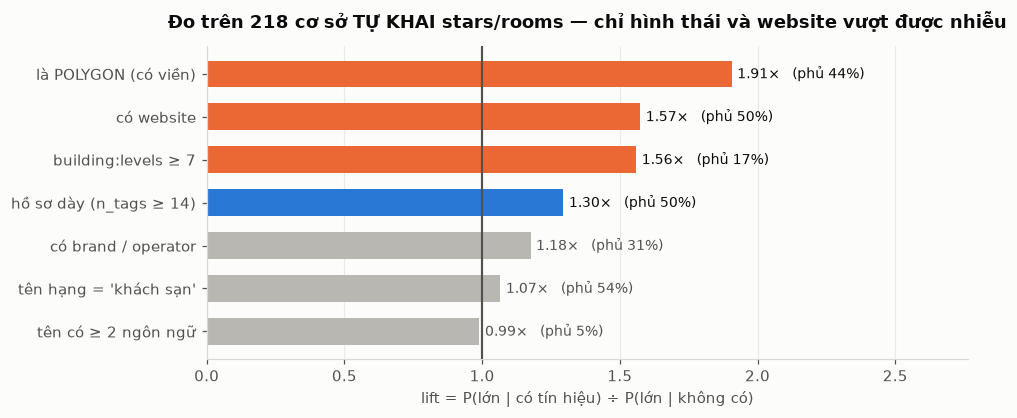

In [7]:
import matplotlib.pyplot as plt

# Bảng màu + rcParams kế thừa từ eda_chungcu (đã chạy validator: CVD ΔE 9,2 · normal 24,0).
# Định nghĩa lại MỘT lần ở đây — notebook phải tự chạy được, không import chéo.
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#b8b7b2"  # "không đủ dữ liệu" — cố ý KHÔNG cấp một hue cho trạng thái này
INK, MUTED, BG = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "axes.edgecolor": "#d9d8d4",
        "axes.grid": True,
        "grid.color": "#ebeae6",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "text.color": INK,
        "axes.labelcolor": MUTED,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)


def fmt(x, n=0):
    """Số kiểu Việt: dấu chấm ngăn nghìn."""
    return f"{x:,.{n}f}".translate(str.maketrans(",.", ".,"))


lodging["levels"] = pd.to_numeric(
    lodging["tags_dict"].map(lambda t: t.get("building:levels")), errors="coerce"
)
lodging["stars_n"] = pd.to_numeric(lodging["stars"], errors="coerce")
lodging["n_lang"] = lodging["tags_dict"].map(lambda t: sum(1 for k in t if k.startswith("name:")))
lodging["co_web"] = lodging["tags_dict"].map(
    lambda t: any(k in t for k in ("website", "contact:website", "url"))
)
lodging["co_addr"] = lodging["tags_dict"].map(lambda t: any(k.startswith("addr:") for k in t))

gold = lodging[lodging["stars_n"].notna() | lodging["rooms"].notna()].copy()
gold["lon"] = gold["stars_n"].ge(3) | gold["rooms"].ge(40)
print(
    f"gold nội bộ (tự khai stars hoặc rooms): {len(gold):,} dòng = {len(gold) / len(lodging):.1%} tập tuyển"
    f" | trong đó 'lớn': {gold['lon'].sum():,} ({gold['lon'].mean():.0%})"
)

UNG_VIEN = {
    "là POLYGON (có viền)": gold["is_area"],
    "có website": gold["co_web"],
    "building:levels ≥ 7": gold["levels"].ge(7).fillna(False),
    "hồ sơ dày (n_tags ≥ 14)": gold["n_tags"].ge(14),
    "có brand / operator": gold["brand"].notna() | gold["operator"].notna(),
    "tên hạng = 'khách sạn'": gold["hang_ten"].eq("khách sạn"),
    "tên có ≥ 2 ngôn ngữ": gold["n_lang"].ge(2),
}
rows = []
for ten, m in UNG_VIEN.items():
    p1 = gold.loc[m, "lon"].mean() if m.sum() else np.nan
    p0 = gold.loc[~m, "lon"].mean() if (~m).sum() else np.nan
    rows.append((ten, m.mean(), p1, p0, p1 / p0 if p0 else np.nan))
cal = pd.DataFrame(rows, columns=["proxy", "phu", "p_lon_co", "p_lon_khong", "lift"]).set_index(
    "proxy"
)
print()
print(
    cal.assign(
        phu=lambda d: (d.phu * 100).round(1),
        p_lon_co=lambda d: (d.p_lon_co * 100).round(1),
        p_lon_khong=lambda d: (d.p_lon_khong * 100).round(1),
        lift=lambda d: d.lift.round(2),
    ).to_string()
)

# Thang HẠNG có phải thang THỨ BẬC thật không — đối chứng với số phòng người map tự khai.
print("\n── hạng theo TÊN đối chứng với quy mô TỰ KHAI (trên gold) ──")
bang_hang = gold.groupby("hang_ten").agg(
    n=("lon", "size"),
    ty_le_lon=("lon", "mean"),
    sao_tv=("stars_n", "median"),
    phong_tv=("rooms", "median"),
)
bang_hang["polygon %"] = (lodging.groupby("hang_ten")["is_area"].mean() * 100).round(0)
print(bang_hang.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 3.9))
c = cal.sort_values("lift")
colors = [ORANGE if v >= 1.5 else (BLUE if v >= 1.25 else GRAY) for v in c["lift"]]
ax.barh(c.index, c["lift"], color=colors, height=0.62)
ax.axvline(1.0, color=MUTED, linewidth=1.4, zorder=4)
ax.annotate("1,0× = proxy vô dụng", (1.0, -0.68), ha="center", va="top", fontsize=8.5, color=MUTED)
for y, (v, phu) in enumerate(zip(c["lift"], c["phu"])):
    ax.text(
        v + 0.02,
        y,
        f"{v:.2f}×   (phủ {phu:.0%})",
        va="center",
        fontsize=9,
        color=INK if v >= 1.25 else MUTED,
    )
ax.set_xlim(0, float(c["lift"].max()) * 1.45)
ax.grid(axis="y", visible=False)
ax.set_xlabel("lift = P(lớn | có tín hiệu) ÷ P(lớn | không có)")
ax.set_title(
    f"Đo trên {fmt(len(gold))} cơ sở TỰ KHAI stars/rooms"
    " — chỉ hình thái và website vượt được nhiễu",
    pad=12,
)
fig.tight_layout()
plt.show()

### REVIEW — chọn thang quy mô

**Soi gì:** 7 ứng viên proxy trên 218 dòng tự khai `stars`/`rooms`.

**Tìm được:**
- **Sự TỒN TẠI của polygon** là proxy mạnh nhất: lift **1,91×**, P(lớn | polygon) = **87,5%**
  so với 45,9% ở node. Câu mở đầu notebook ("`area_m2` vô dụng vì 60% là node") đúng về
  *giá trị* nhưng sai về *sự tồn tại*: người map chỉ bỏ công vẽ viền cho cơ sở đủ lớn.
  Hình thái không phải trở ngại của lớp này — nó là lời khai gián tiếp về quy mô.
- **`n_tags` gần như vô dụng** (1,30×): giả thuyết "hồ sơ dày ⇒ cơ sở lớn" **bị bác**.
- **Tên đa ngôn ngữ chết hẳn ở lớp này** (0,99×). Ghi lại con số này, vì cùng tín hiệu đó
  ở lớp *tham quan* có lift ~10× (nền toàn tập 1,9% so với 20,2% ở `tourism=attraction`).
  Cùng một tín hiệu, hai lớp, hai số phận — đó là lý do cấm bê trục từ lớp này sang lớp kia.
- **Thang HẠNG theo tên là thang thứ bậc THẬT**, không phải cách gọi tuỳ tiện:
  resort 100% lớn / 115 phòng · khách sạn 66% / 40 phòng · homestay 25% / 5,5 phòng ·
  nhà nghỉ 0% / 10 phòng. Bốn bậc, đúng thứ tự, đo bằng con số người map tự khai.

**Quyết định:** thang quy mô = **HẠNG (thứ bậc) × HÌNH THÁI (có polygon hay không)**,
không dùng `n_tags`. Ghi thành hai cột `quy_mo` + `quy_mo_nguon` để downstream biết con số
đến từ lời tự khai hay từ suy luận hình thái.

**Chống lưng:** bảng lift ở trên. **Giới hạn phải ghi nợ:** gold chỉ là 3,8% tập tuyển và
lệch hẳn về nhóm được map kỹ — con số 87,5% **không** ngoại suy thẳng ra 5.698 dòng được.

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 3 — precision: xoá cái CHẮC CHẮN SAI, mỗi luật một cell

Nguyên tắc kế thừa nguyên vẹn từ lớp nhà ở: **tag mô tả VẬT THỂ, tên chỉ là MỐC THAM CHIẾU**.

Nhưng ở lớp này nó phải chạy theo **chiều ngược lại**, và đó là chỗ dễ hỏng nhất: đo trên
tập tuyển được **173/198** dòng (87%) có từ ăn uống trong tên ("Nhà hàng – Khách sạn Cửu
Long", "Son Tra Resort & Spa") **đang mang tag lưu trú cứng**. Ở lớp nhà ở, tên không được cứu tag; ở đây, **tên
không được GIẾT tag**. Cùng một nguyên tắc, chỉ khác dấu.

Các luật GIAO HOÁN: mỗi điều kiện chỉ đọc thuộc tính bất biến của dòng, không luật nào đọc
kết quả của luật khác ⇒ đổi thứ tự cell không đổi tập bị xoá. Thứ tự chỉ quyết định
`drop_reason` gán cho dòng khớp nhiều luật.

In [8]:
candidates = lodging.copy()
for k in [
    "highway",
    "public_transport",
    "railway",
    "aeroway",
    "man_made",
    "historic",
    "natural",
    "waterway",
    "power",
    "barrier",
    "craft",
    "office",
    "shop",
    "landuse",
    "sport",
]:
    candidates[k] = candidates["tags_dict"].map(
        lambda t, k=k: str(t[k]).lower() if k in t else None
    )

remaining = candidates.copy()
# `mixed_use` giữ nguyên là cột hằng False sau khi gỡ khiên: không còn cơ chế nào "tha rồi
# đánh dấu" nữa. Giữ cột để downstream đọc theo schema cũ không vỡ; sẽ bỏ khi đóng ETL.
remaining["mixed_use"] = False
removed_parts = []

LODGING_TAG_CUNG = {
    "hotel",
    "hostel",
    "motel",
    "guest_house",
    "resort",
    "chalet",
    "villa",
    "apartment",
    "love_hotel",
    "alpine_hut",
    "wilderness_hut",
    "camp_site",
    "caravan_site",
}


def co_tag_luu_tru_cung(df):
    """Bằng chứng lưu trú CỨNG — tag TỰ KHAI, không phải tên.

    NGƯỠNG CỦA HÀM NÀY LÀ "ĐỦ ĐỂ KHÔNG BỊ XOÁ", KHÔNG PHẢI "ĐỦ ĐỂ KẾT LUẬN".
    Hai thanh chắn khác nhau, cố ý đặt ở hai độ cao khác nhau:
      · ở đây (bước 3) hỏi "có đủ căn cứ để TÊN không được giết dòng này không?"
      · ở bước 4C hỏi "có đủ căn cứ để GỌI nó là cơ sở lưu trú không?"
    `tourism=apartment` là ca thể hiện rõ nhất: nó nằm trong danh sách này (438 dòng, riêng
    nó cứu 437 dòng khỏi các luật xoá) NHƯNG 257 dòng vẫn bị cắm cờ `CAN_HO_CHUA_KET_LUAN`
    ở bước 4C. Không mâu thuẫn — một tag tự khai luôn đủ để đòi hỏi bằng chứng ngược lại
    trước khi bị xoá, mà chưa chắc đủ để tự nó kết luận. Bỏ `apartment` khỏi đây thì 437
    dòng condotel/căn hộ dịch vụ mất khiên và chết vì tên, đó mới là lỗi thật.
    """
    return (
        df["tourism"].isin(LODGING_TAG_CUNG)
        | df["building"].isin(["hotel", "guest_house"])
        | df["leisure"].isin(["resort", "beach_resort"])
        | df["amenity"].isin(["love_hotel", "hostel"])
        # B5 — khiên PHẢI phủ đúng những gì bước 1 cất công tuyển, nếu không thì một bên
        # cứu, một bên giết. Bước 1 đọc `construction` để không đánh rơi khách sạn ĐANG XÂY;
        # thiếu hai dòng dưới đây thì "Wyndham Soleil Danang" — chính ví dụ của bước 1 —
        # không có khiên và chết ngay ở luật đầu tiên chạm tên nó. Đo được: +2 dòng.
        | df["construction"].isin(["hotel", "hostel", "motel", "guest_house", "resort", "chalet"])
        | df["lifecycle_lodging"]
    )
    # `stars` CỐ Ý không nằm ở đây dù nó là nhánh D của bước 1. Đo trên dữ liệu: OSM VN dùng
    # `stars` cho cả xếp hạng NHÀ HÀNG — "Nhà Hàng Lẩu Cua" (stars=1, amenity=restaurant),
    # "Thái Hoà Viên" (stars=3, restaurant). Đủ tốt để TUYỂN (recall), không đủ để MIỄN TRỪ.


def drop_rule(cond, rule, n=6):
    """Xoá khỏi `remaining`, ghi `removed_parts`, in bằng chứng để soi tại chỗ.

    KHÔNG CÒN KHIÊN TAG. Trước đây hàm này có `tha_co_so_hon_hop=True`: dòng nào mang tag
    lưu trú CỨNG thì được tha khỏi mọi luật xoá, kèm cờ `mixed_use`. Đã GỠ, vì tiền đề của
    nó — "tag tự khai thì đáng tin hơn tên" — không đứng được trên dữ liệu OSM Việt Nam.
    Bằng chứng đo tại chỗ, đây là những dòng khiên từng cứu và trả vào final:
        "Circle K"                        `tourism=hotel`
        "Buu Dien"                        `tourism=guest_house`
        "ĐÀO(dạy kèm)"                    `tourism=apartment`
        "nhà thờ tổ họ lê"                `tourism=apartment`
        "Trung tâm tiệc cưới KIM CƯƠNG"   `tourism=hotel`
    Cộng với hai CỤM TAG SAI HỆ THỐNG đã tìm được (37 dòng `tourism=apartment` ở Bà Rịa–Vũng
    Tàu cũ, 21 dòng `tourism=hostel` tên "nhà ở" ở Hà Nội), kết luận là: ở lớp này KHÔNG có
    thứ gì đáng gọi là bằng chứng "cứng".

    Nguyên tắc thay thế — TÊN QUYẾT ĐỊNH CẢ HAI CHIỀU:
      · tên nói nó là loại khác (quán ăn, cửa hàng, khu du lịch) ⇒ GỠ, bất kể tag;
      · tên nói nó là lưu trú (`HANG_RX_CHAC`) ⇒ GIỮ, và đó là miễn trừ DUY NHẤT.
    Mọi luật dưới vì thế phải giao với `~CO_TU_HANG`, không có ngoại lệ.
    """
    global remaining
    m = cond.reindex(remaining.index, fill_value=False)

    hit = remaining[m]
    print(f"{rule}: xoá {len(hit):,}  →  còn lại {len(remaining) - len(hit):,}")
    print("  mẫu :", hit["name"].dropna().head(n).tolist())

    conflict = hit[co_tag_luu_tru_cung(hit)]
    if len(conflict):
        print(
            f"  ⚠ {len(conflict)} dòng mang tag lưu trú cứng:",
            conflict["name"].dropna().head(8).tolist(),
        )

    removed_parts.append(hit.assign(drop_reason=rule))
    remaining = remaining[~m]


# TẤM KHIÊN của các luật dưới. Nó phải HẸP HƠN `LODGING_RX` dùng để tuyển, và đây là chỗ
# đã trả giá: lấy nguyên `LODGING_RX` làm khiên thì "Pizza Inn", "Mekong Inn" (`\binn\b`),
# "Backpackers Bar" (`backpacker`) được miễn trừ khỏi luật ăn uống và sống sót.
# Khiên chỉ nhận các từ hạng KHÔNG THỂ là thương hiệu quán ăn. Loại khỏi khiên:
# `inn` · `villa/biệt thự` · `lodge` · `residence` · `retreat` — đều là tên quán rất phổ biến.
HANG_RX_CHAC = (
    r"khach san|\bks\b|\bhotel\b|\bhotels\b|khach xa"
    r"|nha nghi|nha khach|\bmotel\b|quan tro"
    r"|homestay|home stay|hostel|guest ?house"
    r"|resort|nghi duong|nghi mat|bungalow|farmstay"
    r"|condotel|can ho dich vu|serviced apartment|apart ?hotel|hometel"
)
CO_TU_HANG = candidates["name_norm"].str.contains(HANG_RX_CHAC, regex=True, na=False)
print(f"tấm khiên HANG_RX_CHAC phủ {CO_TU_HANG.sum():,} dòng"
      f" (so với {candidates['name_norm'].str.contains(LODGING_RX, regex=True, na=False).sum():,}"
      " nếu dùng nguyên regex tuyển)")

print(f"vào bước 3: {len(remaining):,} dòng")
print("giá trị tag chức năng khác đang có mặt:")
for k in [
    "highway",
    "public_transport",
    "amenity",
    "shop",
    "office",
    "leisure",
    "landuse",
    "historic",
    "building",
]:
    v = remaining[k].dropna().value_counts()
    if len(v):
        print(f"  {k:18s} {v.sum():5,} → {v.head(8).to_dict()}")

tấm khiên HANG_RX_CHAC phủ 2,795 dòng (so với 3,040 nếu dùng nguyên regex tuyển)
vào bước 3: 5,698 dòng
giá trị tag chức năng khác đang có mặt:
  highway              117 → {'bus_stop': 117}
  public_transport     119 → {'platform': 117, 'station': 2}
  amenity               73 → {'restaurant': 34, 'cafe': 9, 'love_hotel': 4, 'parking': 3, 'fast_food': 2, 'bar': 2, 'school': 2, 'hostel': 2}
  shop                  27 → {'supermarket': 5, 'convenience': 3, 'travel_agency': 3, 'department_store': 2, 'motorcycle': 2, 'massage': 2, 'pet_grooming': 2, 'ticket': 2}
  office                 7 → {'yes': 3, 'company': 2, 'government': 1, 'notary': 1}
  leisure              142 → {'resort': 102, 'park': 14, 'beach_resort': 10, 'golf_course': 7, 'swimming_pool': 4, 'pitch': 1, 'water_park': 1, 'garden': 1}
  landuse               40 → {'commercial': 25, 'construction': 10, 'military': 2, 'residential': 1, 'retail': 1, 'brownfield': 1}
  historic               4 → {'manor': 2, 'monument': 1, 'memo

In [9]:
# LUẬT 1 — hạ tầng đường. Node `highway=bus_stop` tên "Khách sạn Kim Liên" là TÊN TRẠM,
# không phải khách sạn. Đúng là luật số 1 của lớp nhà ở, và nó vẫn ăn nhiều nhất.
INFRA = (
    remaining["highway"].notna()
    | remaining["public_transport"].notna()
    | remaining["railway"].notna()
    | remaining["aeroway"].notna()
)
print(
    "dòng có tag lưu trú cứng mà vẫn dính luật này:",
    int((INFRA & co_tag_luu_tru_cung(remaining)).sum()),
)
print()
drop_rule(INFRA, "HA_TANG_DUONG")

dòng có tag lưu trú cứng mà vẫn dính luật này: 1

HA_TANG_DUONG: xoá 119  →  còn lại 5,579
  mẫu : ['Khách sạn Sofitel', 'Cạnh ngõ 18 Nguyễn Khoái (Đối diện Vân Đồn Hotel)', '73 Nguyễn Chí Thanh - Đối diện Khách sạn Bảo Sơn', 'Bến số 3b Khách sạn dầu khí - Đồ Sơn', 'Nhà khách Phía Nam', 'Khách sạn Becamex Thành phố Mới']
  ⚠ 1 dòng mang tag lưu trú cứng: ['340-342 Trần Khát Chân']


In [10]:
# LUẬT 2 — "KHU DU LỊCH" KHÔNG phải cơ sở lưu trú. Đây là quyết định RANH GIỚI LỚP và nó có
# số đo chống lưng chứ không phải cảm tính:
#   72 POI tên có "khu du lịch/KDL" trên TẬP TUYỂN → chỉ 6 mang tag lưu trú cứng (8%);
#   trong 41 dòng CÒN LẠI tới cell này (LUẬT 1 đã ăn phần trạm buýt), 10 cái mang
#   `tourism=attraction`, 11 cái `leisure=park`.
#   ⚠ Hai con số trên đo ở HAI TẬP khác nhau — 72 trên tập tuyển, 10/11 trên `remaining`.
# Nguồn tự khai thẳng rằng đa số đây là ĐIỂM ĐẾN THAM QUAN. Bước 1 tuyển chúng vì regex có
# "khu du lich" — đó là lỗi của bước 1; sửa ở đây và gỡ khỏi lexicon khi đóng thành ETL.
# Vẫn tha dòng có tag lưu trú cứng: "KDL sinh thái có bungalow" là chuyện có thật, và ở 7
# tỉnh này CÓ 6 dòng như vậy (`leisure=resort` 5 + `beach_resort` 1) — xem dòng ⊙ in bên dưới.
# `& ~CO_TU_HANG` là phần BÙ cho việc gỡ khiên tag: trước đây luật này không có miễn trừ
# theo tên nào cả, nó dựa hoàn toàn vào tag lưu trú cứng. Nay tên là trọng tài duy nhất,
# nên "KDL sinh thái Ozo Resort" vẫn sống nhờ chữ "resort", còn "Khu du lịch Zenna" thì
# không — đúng ý: tag `leisure=resort` không còn quyền phủ quyết cái tên.
KDL = remaining["name_norm"].str.contains(
    r"khu du lich|\bkdl\b|lang du lich", na=False
) & ~CO_TU_HANG.reindex(remaining.index, fill_value=False)
print(
    "KDL — tag tự khai là gì:", remaining.loc[KDL, "tourism"].value_counts(dropna=False).to_dict()
)
print(
    "             leisure  :",
    remaining.loc[KDL, "leisure"].value_counts(dropna=False).head(4).to_dict(),
)
print()
drop_rule(KDL, "KHU_DU_LICH")

KDL — tag tự khai là gì: {nan: 22, 'attraction': 10, 'artwork': 3, 'theme_park': 3, 'information': 2, 'yes': 1}
             leisure  : {nan: 23, 'park': 11, 'resort': 5, 'beach_resort': 1}

KHU_DU_LICH: xoá 41  →  còn lại 5,538
  mẫu : ['Cổng Khu du lịch Chí Linh', 'KDL Hồng Ph', 'Khu Du Lịch Đại Nam', 'Khu Du Lịch Bình Qưới 2', 'Khu Du Lịch Bình Qưới 1', 'Khu Du Lịch Bình Qưới']
  ⚠ 6 dòng mang tag lưu trú cứng: ['Khu du lịch Quốc Tế Đồi Rồng - Đồ Sơn', 'Khu Du lịch Zenna', 'Khu du lịch Thuỳ Dương', 'Làng Du lịch Chí Linh', 'Khu du lịch New Wave', 'Khu du lịch Bãi Bụt']


In [11]:
# LUẬT 3 — ĂN UỐNG / GIẢI TRÍ ĐÊM. Luật nguy hiểm nhất của notebook: nếu bắt theo TÊN trần
# thì nó tự tay giết một mảng lớn của lớp (173/198 dòng có từ ăn uống trong tên VẪN mang
# tag lưu trú cứng — 87%, tức tên ăn uống gần như KHÔNG có giá trị bác bỏ ở lớp này).
# ⇒ chỉ xoá khi KHÔNG có tag lưu trú cứng VÀ tên KHÔNG mang từ hạng lưu trú nào.
AN_UONG_TAG = remaining["amenity"].isin(
    [
        "restaurant",
        "cafe",
        "fast_food",
        "bar",
        "pub",
        "food_court",
        "ice_cream",
        "biergarten",
        "nightclub",
        "casino",
        "bureau_de_change",
        "atm",
        "parking",
        "community_centre",
        "school",
        "place_of_worship",
        "ferry_terminal",
        "fuel",
        "toilets",
        "bench",
        "bicycle_rental",
    ]
)
AN_UONG_TEN = remaining["name_norm"].str.contains(
    r"nha hang|\bquan an\b|\bquan com\b|\bquan nhau\b|\bquan oc\b|\bcafe\b|\bcf\b|ca phe|coffee"
    r"|\beatery\b|karaoke|\bmassage\b|\bspa\b|bia hoi|\blau \b|buffet|tra sua|\bpho \b|com tam"
    r"|chao vit|\boc dem\b|be thui|can tin|bep an|\bpizza\b|\bbbq\b|\bgrill\b"
    r"|\bnuong\b|hai san|\bkem\b|\bbanh \b|\bbun \b|\bmi \b|\bchao \b",
    na=False,
)
AN_UONG = (AN_UONG_TAG | AN_UONG_TEN) & ~CO_TU_HANG
print(
    f"tên/tag ăn uống tổng cộng: {(AN_UONG_TAG | AN_UONG_TEN).sum():,}"
    f" — trong đó {((AN_UONG_TAG | AN_UONG_TEN) & CO_TU_HANG.reindex(remaining.index, fill_value=False)).sum():,}"
    " có từ hạng lưu trú trong tên ⇒ KHÔNG đụng tới"
)
print()
drop_rule(AN_UONG, "AN_UONG_GIAI_TRI")

tên/tag ăn uống tổng cộng: 239 — trong đó 136 có từ hạng lưu trú trong tên ⇒ KHÔNG đụng tới

AN_UONG_GIAI_TRI: xoá 103  →  còn lại 5,435
  mẫu : ['Nhà Hàng Lẩu Cua', 'Pho Hoi', 'Nhà Hàng Essence', 'Pizza Inn', 'Trọng Khách', 'Thái Hòa Viên']
  ⚠ 77 dòng mang tag lưu trú cứng: ['Pho Hoi', 'Nhà Hàng Essence', 'Trọng Khách', 'Phương Ngân Karaoke', 'Lua Nep', 'NHÀ TỬNG LÂU', 'Khamy Café', 'Café Tin;']


In [12]:
# LUẬT 4 — BÁN LẺ / VĂN PHÒNG / THỦ CÔNG.
# Bắt đúng cái bẫy của nhánh C bước 1: brand chuỗi khách sạn khớp ĐÚNG TẬP ĐOÀN nhưng SAI
# LOẠI HÌNH — "Siêu thị Mường Thanh", "Cửa Hàng Nội Thất Fusion Suites", "Mường Thanh Group",
# "Pullman - W.M. Store". Tập đoàn khách sạn có siêu thị, sân golf, công ty vận tải.
BAN_LE = (
    remaining["shop"].notna()
    | remaining["office"].notna()
    | remaining["craft"].notna()
    | remaining["name_norm"].str.contains(
        r"sieu thi|cua hang|\bshowroom\b|\btap hoa\b|\bdai ly \b|\bgroup\b|cong ty|\bcty\b"
        r"|san bat dong san|\bstore\b|\bphoto\b|cay xang",
        na=False,
    )
) & ~CO_TU_HANG
print()
drop_rule(BAN_LE, "BAN_LE_VAN_PHONG")


BAN_LE_VAN_PHONG: xoá 26  →  còn lại 5,409
  mẫu : ['Circle K', 'CTY TNHH TM KHOI KY SON', 'Công Ty TNHH Thương Mại Dịch Vụ Thái Bảo', 'Cty TNHH TM&DV CUNG ỨNG QUỐC TẾ', 'Siêu thị Mường Thanh H1', 'Siêu thị Mường Thanh H2']
  ⚠ 14 dòng mang tag lưu trú cứng: ['Circle K', 'CTY TNHH TM KHOI KY SON', 'Công Ty TNHH Thương Mại Dịch Vụ Thái Bảo', 'Cty TNHH TM&DV CUNG ỨNG QUỐC TẾ', 'cửa hàng Ba Tí-trạm thu phí Chơn Thành Ql13-120000103244', 'photo sương-ngã tư Chơn Thành-120000099609', 'cây xăng Ngọc Phương Nam-ql13,thành tâm-12', 'gk Hà Giang-Minh Thành,đối diện cty cao su sông bé']


In [13]:
# LUẬT 5 — LƯU TRÚ DÀI HẠN: nhà trọ / phòng trọ / KTX, thuê theo tháng. KHÔNG thuộc lớp này
# (lớp này là lưu trú NGẮN NGÀY) và cũng không thuộc lớp nhà ở đã đi qua.
# `drop_reason` riêng để tra lại được: đây là nguồn cung chỗ ở công nhân/sinh viên, một lớp
# đáng làm riêng sau MVP.
#
# `amenity=motel_month` là tag OSM nói thẳng "thuê tháng" — bước 1 tuyển nó ở nhánh A, đúng
# tinh thần recall, và đây là chỗ trả nó về.
# Neo biên bắt buộc: "tro" trần khớp "Trở", "Trợ" — chỉ dùng cụm hai từ.
NHA_TRO = (
    remaining["name_norm"].str.contains(
        r"nha tro|phong tro|khu tro|cho thue phong|\bktx\b|ky tuc xa", na=False
    )
    | remaining["amenity"].eq("motel_month")
) & ~CO_TU_HANG.reindex(remaining.index, fill_value=False)
# Trước đây luật này có danh sách miễn trừ RIÊNG (`nha nghi|khach san|hotel|homestay|hostel`),
# hẹp hơn `HANG_RX_CHAC` — tức "Nhà trọ Bungalow Cát Bà" được luật khác tha mà luật này xoá.
# Hai danh sách miễn trừ là hai nguồn sự thật; đã gộp về một.
print()
drop_rule(NHA_TRO, "LUU_TRU_DAI_HAN")


LUU_TRU_DAI_HAN: xoá 84  →  còn lại 5,325
  mẫu : ['nhà trọ qua đêm', 'Nhà trọ 162C/6', 'Nhà trọ Nguyễn Thị Nga', 'Nhà trọ Huỳnh Định', 'Nhà trọ DƯơng Thị Tánh', 'Nhà trọ Tán Thanh Huyền']
  ⚠ 83 dòng mang tag lưu trú cứng: ['nhà trọ qua đêm', 'Nhà trọ 162C/6', 'Nhà trọ Nguyễn Thị Nga', 'Nhà trọ Huỳnh Định', 'Nhà trọ DƯơng Thị Tánh', 'Nhà trọ Tán Thanh Huyền', 'Nhà trọ Hoàng Văn Sinh', 'Nhà trọ Trần Văn Hiếu']


In [14]:
# LUẬT 6 — LEISURE không phải lưu trú: sân golf, học viện cưỡi ngựa, hồ bơi, công viên —
# các mảnh của một tập đoàn nghỉ dưỡng được map thành POI riêng ("Vinpearl Golf Haiphong",
# "Học viện cưỡi ngựa Vinpearl Vũ Yên"). `resort`/`beach_resort` KHÔNG nằm đây: đó là nhánh
# tuyển A. Danh sách ĐÓNG ⇒ có chuông giá trị lạ.
# `& ~CO_TU_HANG` bù cho việc gỡ khiên tag — xem docstring `drop_rule`. Không có nó thì
# "Catba Papillon Garden Bungalows & Resort" (`leisure=garden`) chết oan.
LEISURE_KHAC = (
    remaining["leisure"].notna()
    & ~remaining["leisure"].isin(["resort", "beach_resort"])
    & ~CO_TU_HANG.reindex(remaining.index, fill_value=False)
)
LEISURE_BIET = {
    "resort",
    "beach_resort",
    "park",
    "golf_course",
    "swimming_pool",
    "water_park",
    "garden",
    "pitch",
    "sports_hall",
    "horse_riding",
    "fitness_centre",
    "sports_centre",
    "marina",
    "playground",
    "common",
    "nature_reserve",
    "dance",
    "bowling_alley",
    "outdoor_seating",
    "beach_resort",
    "track",
    "amusement_arcade",
}
la = remaining.loc[
    remaining["leisure"].notna() & ~remaining["leisure"].isin(LEISURE_BIET), "leisure"
]
print("⚑ leisure CHƯA PHÂN LOẠI:", la.value_counts().to_dict() or "không có")
print()
drop_rule(LEISURE_KHAC, "LEISURE_KHAC")

⚑ leisure CHƯA PHÂN LOẠI: không có

LEISURE_KHAC: xoá 5  →  còn lại 5,320
  mẫu : ['Vườn hoa Biệt thự Quốc Hội', 'Vinpearl Golf Haiphong', 'Royal Island Golf and Villas', 'Bể bơi NCC Garden Villas', 'Học viện cưỡi ngựa Vinpearl Vũ Yên']


In [15]:
# LUẬT 7 — DI TÍCH / ĐIỂM THAM QUAN. Dinh thự cổ nay là bảo tàng vẫn mang chữ "Biệt thự"
# trong tên: "Bạch Dinh", "Dinh vua Bảo Đại", "Biệt thự Lầu Chú Hoả", "Biệt thự 49 Trần
# Hưng Đạo". Nguồn tự khai `tourism=attraction` / `historic=*` — tag nói thẳng đây là điểm
# tham quan. **Chuyển giao sang lớp THAM QUAN**, không quyết ở đây.
DI_TICH = (
    remaining["tourism"].isin(
        [
            "attraction",
            "museum",
            "artwork",
            "viewpoint",
            "information",
            "theme_park",
            "zoo",
            "aquarium",
            "gallery",
            "picnic_site",
        ]
    )
    | remaining["historic"].notna()
    | (remaining["building"].eq("manor") & remaining["tourism"].isna())
)
print()
drop_rule(DI_TICH, "DI_TICH_THAM_QUAN")


DI_TICH_THAM_QUAN: xoá 13  →  còn lại 5,307
  mẫu : ['Bạch Dinh', 'Dinh vua Bảo Đại', 'Tượng Trận Đánh Cư Xá Brink', 'khách sạn Xanh - đường Hoàng văn Thái', 'Cây đa đại thụ', 'Carmelina khách sạn']


In [16]:
# LUẬT 8 — KHU BIỆT THỰ / KHU Ở, không phải villa cho thuê. "Khu biệt thự cao cấp Thảo Điền",
# "Khu biệt thự Sao Biển 01" — tên mang dáng dự án bất động sản (tên lô + số thứ tự).
#
# Luật này ĐO ĐƯỢC 0 ở 7 tỉnh, và lý do đáng ghi hơn chính con số: cả 10 dòng mang tên kiểu
# này trên tập tuyển đều đã bị LUẬT 1 bắt vì chúng là TRẠM BUÝT lấy khu biệt thự làm mốc
# (10/10 có `highway` hoặc `public_transport`) — đúng nguyên tắc "tên là mốc tham chiếu",
# lần thứ ba trong notebook này.
# Vẫn giữ luật: nó là lưới an toàn cho `SCOPE = "vn"`, nơi khu biệt thự có thể được vẽ thành
# polygon thật. Một luật xoá 0 dòng mà có lý do rõ thì không phải luật thừa.
# Tấm khiên tag cuối cùng của notebook, gỡ cùng lượt với `drop_rule` — miễn trừ chuyển
# sang TÊN cho nhất quán với mọi luật khác.
KHU_O = remaining["name_norm"].str.contains(
    r"khu (?:biet thu|villas?|nha biet thu|do thi|dan cu)", na=False
) & ~CO_TU_HANG.reindex(remaining.index, fill_value=False)
print()
drop_rule(KHU_O, "KHU_O_KHONG_LUU_TRU")


KHU_O_KHONG_LUU_TRU: xoá 0  →  còn lại 5,307
  mẫu : []


In [17]:
# LUẬT 9 — building nói thẳng đây là loại công trình khác ("A25" là brand khách sạn budget
# có thật, nhưng dòng này mang `building=university`). Danh sách GIỮ là danh sách đóng
# ⇒ chuông giá trị lạ.
BUILDING_GIU = {
    "hotel",
    "guest_house",
    "yes",
    "apartments",
    "residential",
    "house",
    "terrace",
    "bungalow",
    "cabin",
    "hut",
    "detached",
    "dormitory",
    "roof",
    "construction",
}
# Lớp nhà ở ở LUẬT 6 xoá `building=hotel` vô điều kiện vì tag CẤU TRÚC thắng tên THƯƠNG HIỆU.
# Ở đây từng làm ngược lại — miễn trừ theo `tourism` với lý do "`building` mô tả CÁI VỎ,
# `tourism` mô tả CHỨC NĂNG". Lý lẽ đó ĐÃ BỎ cùng tấm khiên tag: `tourism` ở OSM VN không
# đáng tin hơn `building` chút nào (Circle K mang `tourism=hotel`). Nay miễn trừ theo TÊN.
# Khách sạn thuê nguyên toà văn phòng vẫn là chuyện thật: đo trên tập tuyển được ĐÚNG 1
# dòng `building=office` + tag lưu trú cứng — "Khách sạn & Suites JW Marriott Sài Gòn".
# Nới ra MỌI giá trị `building` ngoài danh sách GIU thì được 6 dòng (thêm Bel Marina Hoi An
# Resort, Central Hotel, Hai Yen Luxury Hotel, ...) — đó mới là số dòng khiên thực sự cứu.
# Miễn trừ đổi từ TAG sang TÊN cùng lúc với việc gỡ khiên: "khách sạng mường thanh"
# (`building=commercial`) sống nhờ chữ "khách sạn" trong tên, không nhờ `tourism=hotel`.
BUILDING_KHAC = (
    remaining["building"].notna()
    & ~remaining["building"].isin(BUILDING_GIU)
    & ~CO_TU_HANG.reindex(remaining.index, fill_value=False)
)
la = remaining.loc[BUILDING_KHAC, "building"]
print("⚑ building bị luật này bắt:", la.value_counts().to_dict() or "không có")
print()
drop_rule(BUILDING_KHAC, "BUILDING_KHAC")

⚑ building bị luật này bắt: {'commercial': 2, 'university': 1}

BUILDING_KHAC: xoá 3  →  còn lại 5,304
  mẫu : ['A25', 'Hometown Bamboo Prime Villa']
  ⚠ 2 dòng mang tag lưu trú cứng: ['Hometown Bamboo Prime Villa']


In [18]:
# LUẬT 10 — tên nói thẳng là loại công trình khác. Danh sách HẸP và neo biên chặt:
# "truong " trần khớp "Nhà Nghỉ Trường Thuỷ", "Trường Giang" — đó là TÊN RIÊNG, không phải
# trường học. Chỉ giữ cụm không thể là tên riêng.
TEN_LOAI_KHAC = (
    remaining["name_norm"].str.contains(
        r"benh vien|phong kham|\bubnd\b|uy ban nhan dan|\bcong an\b|toa an|vien kiem sat|kho bac"
        r"|buu dien|\bngan hang\b|nha may|xi nghiep|\bkcn\b|khu cong nghiep|tram thu phi|\btba\b"
        r"|tram bien ap|truong (?:tieu hoc|thcs|thpt|mam non|mau giao|dai hoc|cao dang|nghe)"
        r"|\btram y te\b|nha tang le|tiec cuoi|nha tho (?:to|ho|dong)",
        na=False,
    )
    & ~CO_TU_HANG
)
print()
drop_rule(TEN_LOAI_KHAC, "TEN_LOAI_KHAC")


TEN_LOAI_KHAC: xoá 12  →  còn lại 5,292
  mẫu : ['Buu Dien', 'Trung tâm tiệc cưới - hội nghị KIM CƯƠNG', 'Trung tâm hội nghị - tiệc cưới Ruby palace', 'nhà thờ tổ họ lê', 'Khu Nội Trú Lưu Học Sinh Lào - Trường Đại Học SP TDTT Hà Nội', 'TBA Do Nha 2']
  ⚠ 12 dòng mang tag lưu trú cứng: ['Buu Dien', 'Trung tâm tiệc cưới - hội nghị KIM CƯƠNG', 'Trung tâm hội nghị - tiệc cưới Ruby palace', 'nhà thờ tổ họ lê', 'Khu Nội Trú Lưu Học Sinh Lào - Trường Đại Học SP TDTT Hà Nội', 'TBA Do Nha 2', 'tiệc cưới Trung Kiên-chợ mới Thành Tâm-120000095962', 'trường thcs Minh Lập-Minh Lập-']


In [19]:
# LUẬT 11 — MỐC THAM CHIẾU: tên mở đầu bằng giới từ vị trí ⇒ POI là điểm TRỎ TỚI khách sạn,
# không phải khách sạn. Bài học nguyên văn của lớp nhà ở: chỉ giữ tiền tố KHÔNG thể là tên
# riêng. "canh " bị loại khỏi danh sách vì khớp "Cảnh Viên"; "gan " khớp "Gấn".
MOC = remaining["name_norm"].str.contains(
    r"^(?:doi dien|truoc cong|he truoc|he doi dien|diem xen|cong khu|ben canh|duong vao"
    r"|ngo vao|loi vao|qua san)",
    na=False,
)
print()
drop_rule(MOC, "MOC_THAM_CHIEU")


MOC_THAM_CHIEU: xoá 0  →  còn lại 5,292
  mẫu : []


### Bước 3B — một CỤM TAG SAI HỆ THỐNG, đo trước rồi mới xoá

Không phải mọi nhiễu đều là nhiễu ngẫu nhiên. Cell dưới đo một **dị thường theo vùng**:
`tourism=apartment` ở Đồng Nai có tỷ lệ cao bất thường, và hồ sơ của chúng thoái hoá
(100% node, trung vị 2 tag, không địa chỉ), tên là quán ăn / căn tin / cây xăng / trạm
biến áp, nhiều tên còn đính **mã khảo sát 9–12 chữ số** ở đuôi — dấu vân tay của một đợt
nhập liệu hàng loạt gắn sai preset.

Đây là biến thể của bài học `residential=rural` gắn cho KĐT Sala ở lớp nhà ở: **dữ liệu VN
có tag sai HỆ THỐNG, không tin mù một tag đơn lẻ**. Khác ở chỗ lần này cái sai gom cụm
theo địa lý nên đo được, và phải đo trước khi xoá.

In [20]:
# Chữ ký của cụm, xếp theo độ chắc:
#   1. MÃ KHẢO SÁT ở đuôi tên `-\d{9,}` — 100% nhóm này là `tourism=apartment`, không dòng
#      nào là cơ sở lưu trú. Đây là đầu dò gần như tuyệt đối, KHÔNG cần điều kiện tỉnh.
#   2. hồ sơ thoái hoá: `tourism=apartment` là tag phân loại DUY NHẤT + node + không địa chỉ,
#      và tên KHÔNG có một từ hạng lưu trú nào.
# Điều kiện (2) một mình quá rộng (bắt cả "Nhà Khách Mia House") nên phải giao với (1) hoặc
# với từ vựng phi-lưu-trú — phần lớn nhóm đó đã bị LUẬT 3/4/10 dọn, cell này đo phần còn lại.
_ap = candidates["tourism"].eq("apartment")
print("── dị thường theo vùng: tỷ lệ `tourism=apartment` trên tổng POI của tỉnh ──")
tong_tinh = poi["province_name"].value_counts()
ty_le = (
    (candidates.loc[_ap, "province_name"].value_counts() / tong_tinh * 100)
    .dropna()
    .sort_values(ascending=False)
)
print(ty_le.round(3).to_string())
print(
    f"\ncao nhất / thấp nhất = {ty_le.max() / ty_le.min():.1f}× — không phải chênh lệch ngẫu nhiên"
)

MA_KHAO_SAT = remaining["name"].fillna("").str.contains(r"-\d{9,}", na=False)
print(f"\ncòn lại trong `remaining` có mã khảo sát ở đuôi tên: {MA_KHAO_SAT.sum()}")
print(
    "  tourism của nhóm:",
    remaining.loc[MA_KHAO_SAT, "tourism"].value_counts(dropna=False).to_dict(),
)

HO_SO_THOAI_HOA = (
    remaining["tourism"].eq("apartment")
    & ~remaining["is_area"]
    & remaining["n_tags"].le(3)
    & ~remaining["co_addr"]
    & ~CO_TU_HANG
    & remaining["province_name"].isin(ty_le[ty_le > 2 * ty_le.median()].index)  # chỉ vùng dị thường
)
print(f"hồ sơ thoái hoá trong vùng dị thường: {HO_SO_THOAI_HOA.sum()}")
print("  mẫu:", remaining.loc[HO_SO_THOAI_HOA, "name"].dropna().head(10).tolist())
print()
drop_rule(MA_KHAO_SAT | HO_SO_THOAI_HOA, "TAG_SAI_HE_THONG", n=10)

── dị thường theo vùng: tỷ lệ `tourism=apartment` trên tổng POI của tỉnh ──
province_name
Tỉnh Đồng Nai            0.698
Thành phố Đà Nẵng        0.340
Thành phố Hải Phòng      0.267
Thành phố Hồ Chí Minh    0.257
Thành phố Hà Nội         0.074
Thành phố Cần Thơ        0.044
Tỉnh Quảng Ninh          0.040

cao nhất / thấp nhất = 17.4× — không phải chênh lệch ngẫu nhiên

còn lại trong `remaining` có mã khảo sát ở đuôi tên: 31
  tourism của nhóm: {'apartment': 31}
hồ sơ thoái hoá trong vùng dị thường: 75
  mẫu: ['nha Phuong Nghia', 'hồ bơi Khánh Linh-Thành Tâm,Chơn Thành-120000095965', 'th Huệ', 'th cô Trang-ql14,t.t chơn thành-120000095936', 'th Trung Bình-ngã tư Minh Thành-120000094181', 'vpp Nhật Huy-ql14 nha bích-120000099608', 'lò gạch nha Bích-Nha Bích, đường đi Tân Quan-120000090143', 'TH chị Nhàn-chợ Minh Lập-120000065822', 'TH Tư Hùng-ql14,Minh Lập-120000046719', 'th phương hạnh']

TAG_SAI_HE_THONG: xoá 76  →  còn lại 5,216
  mẫu : ['nha Phuong Nghia', 'th Ánh Tuyết-ấp 2 trừ văn

### REVIEW — cụm tag sai hệ thống

**Soi gì:** phân bố `tourism=apartment` theo tỉnh, hồ sơ tag của nhóm dị thường, và 200
mẫu tên đọc bằng subagent.

**Nhận xét:** Đồng Nai có 135 `tourism=apartment` trên 19.336 POI (0,70%) so với TP.HCM
150/58.358 (0,26%) — chênh 2,7×. Nhóm Đồng Nai: **100% node**, trung vị **2 tag**
(`tourism` + `name`, không gì khác), tên là "căn tin cty megatech-kcn Chơn Thành",
"cf hoa nắng-kcn Chơn Thành-120000101294", "TBA Do Nha 2". Địa danh trong tên (Chơn Thành,
Thành Tâm, Lộc Ninh) là các xã của **Bình Phước cũ**, nay thuộc Đồng Nai theo niên bản
địa giới 16/6/2025 — tức một đợt khảo sát của một địa phương, nhập bằng một preset sai.

**Quyết định:** xoá với `drop_reason = "TAG_SAI_HE_THONG"` (tra lại được), dùng đầu dò
**mã khảo sát ở đuôi tên** làm tín hiệu chính vì nó không phụ thuộc tỉnh nên còn chạy đúng
khi `SCOPE = "vn"`; điều kiện vùng dị thường được **tính từ dữ liệu** (ngưỡng 2× trung vị
của chính bảng tỷ lệ), không hardcode tên tỉnh.

**Chống lưng:** bảng tỷ lệ theo tỉnh + hồ sơ tag ở trên. **Nợ:** chưa báo lỗi ngược lên
OSM; và nếu đợt nhập liệu tương tự tồn tại ở tỉnh khác mà không đính mã khảo sát thì đầu
dò này không thấy.

→ TỰ PHÊ DUYỆT, đi tiếp.

In [21]:
# CỔNG HẬU KIỂM — chạy SAU toàn bộ luật.
#
# BẤT BIẾN CỦA CỔNG NÀY ĐÃ ĐỔI cùng lúc với việc gỡ khiên tag (xem docstring `drop_rule`).
# Bản cũ canh "dòng mang tag lưu trú CỨNG bị xoá ⇒ luật quá tay" và assert ≤ 30. Bất biến
# đó chết theo tấm khiên: nay tag KHÔNG còn là bằng chứng bảo vệ, nên xoá một dòng
# `tourism=hotel` tên "Circle K" là ĐÚNG Ý, không phải tai nạn. Giữ assert cũ thì cổng đỏ
# vĩnh viễn vì đúng cái hành vi ta vừa cố tình bật.
#
# Bất biến MỚI, khớp nguyên tắc "tên quyết định cả hai chiều":
#   ⇒ KHÔNG dòng nào có TỪ HẠNG lưu trú trong tên (`HANG_RX_CHAC`) được phép bị xoá bởi một
#     luật NGOÀI Ý. Tên là trọng tài duy nhất, nên vi phạm nó mới là lỗi thật sự vá được.
# Số dòng mang tag lưu trú bị xoá vẫn ĐO và IN — nó là thước cho biết tag OSM sai tới mức
# nào, chỉ không còn là điều kiện đỏ.
removed = pd.concat(removed_parts)
assert len(removed) + len(remaining) == len(candidates), "thất thoát dòng giữa các luật"

# Hai nhóm luật được miễn khỏi bất biến, vì hai lý do KHÁC NHAU:
#   · ranh giới lớp — dòng đúng là lưu trú nhưng không thuộc lớp này (nhà trọ dài hạn),
#     hoặc đúng là thứ khác dù mang tag lưu trú (khu du lịch, di tích, khu ở, tag sai cụm);
#   · TÊN LÀ MỐC — `HA_TANG_DUONG` và `MOC_THAM_CHIEU` bắt những dòng mà cái tên chứa
#     "Khách sạn Sofitel" chỉ vì nó là TÊN TRẠM BUÝT đứng cạnh khách sạn đó. Ở đây vật thể
#     tự khai là hạ tầng (`highway`/`public_transport`) — bằng chứng CẤU TRÚC, không phải
#     tag chức năng — nên nó vẫn thắng cái tên. Đây là ngoại lệ DUY NHẤT còn lại của
#     nguyên tắc "tên là trọng tài", và nó có lý do vật lý chứ không phải lý do tag.
LUAT_CO_Y = {"LUU_TRU_DAI_HAN", "KHU_DU_LICH", "DI_TICH_THAM_QUAN", "KHU_O_KHONG_LUU_TRU",
             "TAG_SAI_HE_THONG", "HA_TANG_DUONG", "MOC_THAM_CHIEU"}
# --- ĐO (không chặn): tag OSM sai tới mức nào ---
conflict = removed[co_tag_luu_tru_cung(removed)]
print(f"POI mang tag lưu trú nhưng bị xoá: {len(conflict)} — phân theo luật:")
print(conflict["drop_reason"].value_counts().to_string())
print(f"\n  trong đó do LUẬT CÓ Ý (ranh giới lớp): {conflict['drop_reason'].isin(LUAT_CO_Y).sum()}")
print(f"  do luật khác — TAG SAI, tên đúng     : {(~conflict['drop_reason'].isin(LUAT_CO_Y)).sum()}")
print("  mẫu nhóm sau (đây là thứ khiên tag từng cứu và trả vào final):")
print(
    conflict[~conflict["drop_reason"].isin(LUAT_CO_Y)][
        ["name", "tourism", "building", "leisure", "amenity", "drop_reason"]
    ].head(15).to_string()
)

# --- CHẶN: tên nói nó là lưu trú thì không luật NGOÀI Ý nào được đụng ---
ten_khai_hang = removed["name_norm"].str.contains(HANG_RX_CHAC, regex=True, na=False)
vi_pham = removed[ten_khai_hang & ~removed["drop_reason"].isin(LUAT_CO_Y)]
print(f"\n── VI PHẠM bất biến (tên có từ hạng + luật NGOÀI Ý xoá): {len(vi_pham)} ──")
if len(vi_pham):
    print(vi_pham[["name", "tourism", "drop_reason"]].head(30).to_string())
assert len(vi_pham) == 0, (
    f"{len(vi_pham)} dòng tên tự khai hạng lưu trú bị luật NGOÀI Ý xoá — tên là trọng tài"
    " duy nhất, luật nào bắt chúng là quá tay"
)

print("\n== tổng hợp theo luật ==")
print(removed["drop_reason"].value_counts().to_string())
print("\n== luật dọn hạng nào ==")
print(
    removed.groupby("hang_ten")["drop_reason"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)
print(f"\n== cột mixed_use: {remaining['mixed_use'].sum()} (khiên tag đã gỡ — cột nay luôn 0) ==")

print("\n== nhóm rủi ro nhất: tên có 'khách sạn/hotel' mà vẫn bị xoá ==")
risky = removed[removed["name_norm"].str.contains(r"khach san|\bhotel\b", na=False)]
print(f"{len(risky)} dòng — {risky['drop_reason'].value_counts().to_dict()}")
print(" ", risky["name"].dropna().head(10).tolist())

POI mang tag lưu trú nhưng bị xoá: 271 — phân theo luật:
drop_reason
LUU_TRU_DAI_HAN     83
AN_UONG_GIAI_TRI    77
TAG_SAI_HE_THONG    76
BAN_LE_VAN_PHONG    14
TEN_LOAI_KHAC       12
KHU_DU_LICH          6
BUILDING_KHAC        2
HA_TANG_DUONG        1

  trong đó do LUẬT CÓ Ý (ranh giới lớp): 166
  do luật khác — TAG SAI, tên đúng     : 105
  mẫu nhóm sau (đây là thứ khiên tag từng cứu và trả vào final):
                           name      tourism building leisure     amenity       drop_reason
4734                    Pho Hoi        hotel      NaN     NaN         NaN  AN_UONG_GIAI_TRI
4948           Nhà Hàng Essence        hotel      NaN     NaN  restaurant  AN_UONG_GIAI_TRI
5483                Trọng Khách        hotel      NaN     NaN  restaurant  AN_UONG_GIAI_TRI
12311       Phương Ngân Karaoke        hotel      NaN     NaN         NaN  AN_UONG_GIAI_TRI
12675                   Lua Nep        hotel      NaN     NaN  restaurant  AN_UONG_GIAI_TRI
14713              NHÀ TỬNG LÂU  guest_

In [22]:
clean = remaining.copy()
out_keep = EDA_DIR / f"poi_luutru_{SCOPE}_b3.parquet"
out_drop = EDA_DIR / f"poi_luutru_{SCOPE}_b3_bi_xoa.parquet"
clean.drop(columns="tags_dict").to_parquet(out_keep, index=False)
removed.drop(columns="tags_dict").to_parquet(out_drop, index=False)
print(f"giữ : {len(clean):,} → {out_keep.name}")
print(f"xoá : {len(removed):,} → {out_drop.name}\n")

# Tỷ lệ SỐNG SÓT theo nhánh tuyển — căn cứ đánh giá chất lượng từng nhánh, đo SAU khi lọc,
# không phải điểm gán sẵn lúc tuyển.
print("tỷ lệ sống sót theo nhánh tuyển bước 1:")
for ten, m in {
    "A tag": LODGING_TAG,
    "B tên": LODGING_NAME,
    "C chuỗi KS": LODGING_CHAIN,
    "D stars": LODGING_STARS,
}.items():
    tong = int(m.reindex(candidates.index, fill_value=False).sum())
    song = int(m.reindex(clean.index, fill_value=False).sum())
    print(f"  {ten:12s} {song:5,}/{tong:<5,} = {song / tong:.0%}" if tong else f"  {ten:12s} —")
print()
print(clean["hang_ten"].value_counts().to_string())

giữ : 5,216 → poi_luutru_7tinh_b3.parquet
xoá : 482 → poi_luutru_7tinh_b3_bi_xoa.parquet

tỷ lệ sống sót theo nhánh tuyển bước 1:
  A tag        5,138/5,410 = 95%
  B tên        2,854/3,040 = 94%
  C chuỗi KS     121/149   = 81%
  D stars        126/135   = 93%

hang_ten
(tên không nói hạng)    2379
khách sạn               1807
homestay / hostel        472
nhà nghỉ / nhà khách     282
resort / nghỉ dưỡng      159
villa / biệt thự         111
căn hộ DV / condotel       6


### PS1: hiện tại là 5698, tuy nhiên xuất hiện các lỗi trong insight ví dụ: có chứa các keyword như nhà ở, nhà rieeng, cf, truươờ mẫu giáo,.. cần update rule để loại bỏ

### PS2: hiện tại là 5216

## Bước 4 — ĐO, không quyết

Ba phép đo, không phép nào xoá dòng nào:

- **4A quy mô** — dịch bằng chứng của bước 2 thành hai cột `quy_mo` / `quy_mo_nguon`.
- **4B đếm CƠ SỞ, không đếm dòng** — bài học đắt nhất của lớp nhà ở (đếm thô thổi 58%).
  Ở đây bệnh khác: 19 way nhỏ vô danh `leisure=resort` nằm gọn trong một resort lớn là
  các bungalow của cùng một cơ sở.
- **4C polygon quá to** — 675 ha thì không phải một cơ sở lưu trú, đó là ranh giới VÙNG.

quy_mo
KHONG_DO_DUOC           3693
LON_SUY_TU_HINH_THAI    1183
LON_TU_KHAI              214
NHO_TU_KHAI              126

quy_mo                KHONG_DO_DUOC  LON_SUY_TU_HINH_THAI  LON_TU_KHAI  NHO_TU_KHAI
hang_ten                                                                           
(tên không nói hạng)           1516                   749           72           42
căn hộ DV / condotel              4                     0            1            1
homestay / hostel               439                    12            4           17
khách sạn                      1341                   294          119           53
nhà nghỉ / nhà khách            228                    43            5            6
resort / nghỉ dưỡng              72                    73           10            4
villa / biệt thự                 93                    12            3            3


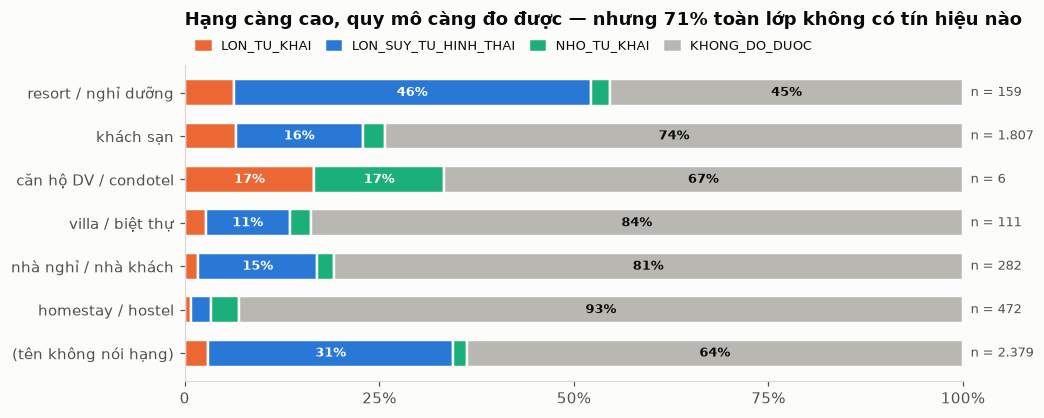

In [23]:
# [DATA] sinh cột: quy_mo, quy_mo_nguon
# 4A — dịch bằng chứng bước 2 thành nhãn. KHÔNG đo thêm gì.
#
# Ngưỡng "lớn" (3 sao / 40 phòng / 7 tầng) là ĐẶT TAY, ghi rõ ở đây: 3 sao là mốc hành chính
# của phân hạng lưu trú VN; 40 phòng là trung vị số phòng của nhóm tự khai `khách sạn`.
# Bậc `suy_tu_hinh_thai` KHÔNG được đọc là "chắc chắn lớn" — xem nợ ở phần chốt lớp.
SAO_LON, PHONG_LON, TANG_LON = 3, 40, 7

tu_khai = clean["stars_n"].notna() | clean["rooms"].notna() | clean["levels"].notna()
lon_tu_khai = (
    clean["stars_n"].ge(SAO_LON) | clean["rooms"].ge(PHONG_LON) | clean["levels"].ge(TANG_LON)
)

clean["quy_mo"] = np.select(
    [tu_khai & lon_tu_khai, tu_khai & ~lon_tu_khai, ~tu_khai & clean["is_area"]],
    ["LON_TU_KHAI", "NHO_TU_KHAI", "LON_SUY_TU_HINH_THAI"],
    default="KHONG_DO_DUOC",
)
clean["quy_mo_nguon"] = np.select(
    [tu_khai, clean["is_area"]], ["tu_khai", "hinh_thai"], default="khong_co"
)

print(clean["quy_mo"].value_counts().to_string())
print()
print(pd.crosstab(clean["hang_ten"], clean["quy_mo"]).to_string())

fig, ax = plt.subplots(figsize=(9.6, 3.9))
QM_ORDER = ["LON_TU_KHAI", "LON_SUY_TU_HINH_THAI", "NHO_TU_KHAI", "KHONG_DO_DUOC"]
QM_COLOR = {
    "LON_TU_KHAI": ORANGE,
    "LON_SUY_TU_HINH_THAI": BLUE,
    "NHO_TU_KHAI": GREEN,
    "KHONG_DO_DUOC": GRAY,
}
HANG_ORDER = [
    h
    for h in [
        "resort / nghỉ dưỡng",
        "khách sạn",
        "căn hộ DV / condotel",
        "villa / biệt thự",
        "nhà nghỉ / nhà khách",
        "homestay / hostel",
        "(tên không nói hạng)",
    ]
    if h in set(clean["hang_ten"])
]
tab = (
    pd.crosstab(clean["hang_ten"], clean["quy_mo"])
    .reindex(index=HANG_ORDER, columns=QM_ORDER)
    .fillna(0)
)
share = tab.div(tab.sum(axis=1), axis=0)
left = np.zeros(len(tab))
for q in QM_ORDER:
    v = share[q].values
    ax.barh(tab.index, v, left=left, color=QM_COLOR[q], height=0.62, edgecolor=BG, linewidth=1.6)
    for y, (p, n) in enumerate(zip(v, tab[q].values)):
        if p > 0.07:
            ax.text(
                left[y] + p / 2,
                y,
                f"{p:.0%}",
                ha="center",
                va="center",
                fontsize=8.5,
                color="#ffffff" if q != "KHONG_DO_DUOC" else INK,
                fontweight="bold",
            )
    left += v
for y, ten in enumerate(tab.index):
    ax.text(1.01, y, f"n = {fmt(tab.loc[ten].sum())}", va="center", fontsize=8.5, color=MUTED)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(["0", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
ax.grid(visible=False)
ax.set_title(
    f"Hạng càng cao, quy mô càng đo được — nhưng {clean['quy_mo'].eq('KHONG_DO_DUOC').mean():.0%}"
    " toàn lớp không có tín hiệu nào",
    pad=26,
    loc="left",
)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=QM_COLOR[q]) for q in QM_ORDER],
    labels=QM_ORDER,
    ncol=4,
    loc="lower left",
    bbox_to_anchor=(0, 1.0),
    frameon=False,
    fontsize=8.5,
    handlelength=1.1,
    columnspacing=1.2,
)
fig.tight_layout()
plt.show()

In [24]:
# [DATA] sinh cột: container_uid, fragment_group
# 4B — ĐẾM CƠ SỞ, KHÔNG ĐẾM DÒNG. Bài học đắt nhất của lớp nhà ở, kiểm lại ở lớp này.
# Bệnh cụ thể ở đây: các way nhỏ vô danh `leisure=resort` (99–868 m², Đà Nẵng) nằm gọn trong
# một resort lớn — đó là bungalow/villa con của CÙNG MỘT cơ sở, không phải 19 cơ sở.
from shapely import wkb
from shapely.geometry import Point
from shapely.strtree import STRtree

PTS = [Point(x, y) for x, y in zip(clean["lng"].values, clean["lat"].values)]
TREE = STRtree(PTS)
UIDS = clean["uid"].values

vung = clean[clean["is_area"] & clean["geometry_wkb"].notna()].copy()
vung["_geom"] = [wkb.loads(bytes(x)) for x in vung["geometry_wkb"]]
vung = vung[[g.is_valid and g.area > 0 for g in vung["_geom"]]]

container = {}
for i, geom in vung.sort_values("area_m2", ascending=False)["_geom"].items():
    self_uid = vung.at[i, "uid"]
    idx = TREE.query(geom)
    if not len(idx):
        continue
    for j in idx[[geom.contains(PTS[k]) for k in idx]]:
        if UIDS[j] != self_uid:
            container[UIDS[j]] = self_uid  # polygon nhỏ ghi đè polygon to ⇒ container SÁT nhất

clean["container_uid"] = clean["uid"].map(container)

# fragment_group: cùng tên trong cùng ô H3 r8 (~0,7 km²). Phạm vi H3 là bắt buộc —
# "Hoa Sen Hotel" ở hai đầu đất nước là hai cơ sở khác nhau.
co_ten = clean["name"].notna()
key = clean.loc[co_ten, ["h3_r8", "name_norm"]].astype(str).agg("|".join, axis=1)
clean["fragment_group"] = key[key.duplicated(keep=False)].reindex(clean.index)

n_row, n_ct = len(clean), int(clean["container_uid"].notna().sum())
print(
    f"dòng lưu trú nằm TRONG một polygon lưu trú khác: {n_ct:,}"
    f"  → đếm CƠ SỞ: {n_row - n_ct:,} thay vì {n_row:,} ({n_ct / n_row:.1%} là đếm đôi)"
)
print(
    f"nhóm mảnh trùng tên trong cùng ô H3: {clean['fragment_group'].nunique():,} nhóm,"
    f" {clean['fragment_group'].notna().sum():,} dòng"
)
print("\n5 polygon chứa nhiều dòng con nhất:")
top = clean["container_uid"].value_counts().head(5)
for u, k in top.items():
    ten = clean.loc[clean["uid"].eq(u), "name"].fillna("(vô danh)").iloc[0]
    print(f"  {u:22s} {k:3d} dòng con — {ten}")

dòng lưu trú nằm TRONG một polygon lưu trú khác: 476  → đếm CƠ SỞ: 4,740 thay vì 5,216 (9.1% là đếm đôi)
nhóm mảnh trùng tên trong cùng ô H3: 60 nhóm, 188 dòng

5 polygon chứa nhiều dòng con nhất:
  way:513706286          121 dòng con — Danang Marriott Resort & Spa, Non Nuoc Beach Villas
  way:486214075           83 dòng con — Furama Villas
  way:513706270           39 dòng con — Meliá Danang Beach Resort
  way:514050022           25 dòng con — Agribank Hoi An Beach Resort
  way:500748719           20 dòng con — Boutique Hội An Resort


In [25]:
# [DATA] sinh cột: verdict
# 4C — polygon quá TO thì không phải một cơ sở lưu trú mà là ranh giới VÙNG.
# Để dữ liệu chọn ngưỡng: quét phân vị diện tích của nhóm polygon có tag lưu trú cứng.
poly = clean[clean["is_area"] & clean["area_m2"].gt(0)].copy()
poly["ha"] = poly["area_m2"] / 1e4
q = poly["ha"].quantile([0.5, 0.9, 0.95, 0.99]).round(2)
print(
    f"diện tích polygon lưu trú (ha): trung vị {q[0.5]} · p90 {q[0.9]} · p95 {q[0.95]} · p99 {q[0.99]}"
)

# Ngưỡng 50 ha: nằm giữa p95 và p99, và soi tay nhóm vượt cho thấy toàn là sân golf /
# dự án BĐS nghỉ dưỡng ("NOVALAND Hồ Tràm", "FLC Ha Long Bay Golf Club") — vùng, không phải
# khối phòng. Là ngưỡng ĐẶT TAY, ghi rõ.
HA_VUNG = 50
clean["verdict"] = np.where(
    clean["is_area"] & clean["area_m2"].gt(HA_VUNG * 1e4), "VUNG_KHONG_PHAI_CO_SO", None
)
n_vung = int(clean["verdict"].eq("VUNG_KHONG_PHAI_CO_SO").sum())
print(f"\npolygon > {HA_VUNG} ha ⇒ cờ VUNG_KHONG_PHAI_CO_SO: {n_vung}")
print(
    clean.loc[clean["verdict"].notna(), ["name", "area_m2", "hang_ten", "province_name"]]
    .assign(ha=lambda d: (d.area_m2 / 1e4).round(1))
    .drop(columns="area_m2")
    .to_string()
)

# Nhóm CHƯA KẾT LUẬN: `tourism=apartment` hồ sơ mỏng, tên là tên người/biệt danh. Subagent
# đọc 200 mẫu: 74% không phân định được lưu trú-ngắn-ngày hay nhà-ở-dài-hạn từ tên.
# Ghi CỜ chứ không ép nhãn — "tự phê duyệt" nghĩa là không dừng chờ, không phải ép kết luận.
KHONG_RO = (
    clean["tourism"].eq("apartment")
    & ~clean["name_norm"].str.contains(LODGING_RX, regex=True, na=False)
    & ~clean["is_area"]
)
clean.loc[KHONG_RO & clean["verdict"].isna(), "verdict"] = "CAN_HO_CHUA_KET_LUAN"
print(
    f"\ncăn hộ chưa kết luận (tourism=apartment, node, tên không nói hạng): {int(KHONG_RO.sum()):,}"
)
print("  mẫu:", clean.loc[KHONG_RO, "name"].dropna().head(8).tolist())
print("\ncờ verdict:", clean["verdict"].value_counts(dropna=False).to_dict())

diện tích polygon lưu trú (ha): trung vị 0.03 · p90 0.53 · p95 2.82 · p99 19.72

polygon > 50 ha ⇒ cờ VUNG_KHONG_PHAI_CO_SO: 10
                                             name              hang_ten          province_name      ha
113912                 CLB Golf Vũng Tàu Paradise   resort / nghỉ dưỡng  Thành phố Hồ Chí Minh   126.6
130452                     BRG Danang Golf Resort   resort / nghỉ dưỡng      Thành phố Đà Nẵng   203.0
145531                  Sky Lake Resort Golf Club   resort / nghỉ dưỡng       Thành phố Hà Nội   305.5
150365                        Sông Bé Golf Resort   resort / nghỉ dưỡng  Thành phố Hồ Chí Minh   106.2
155397                              Xã Nghi Dương   resort / nghỉ dưỡng    Thành phố Hải Phòng  2030.9
175329  FLC Ha Long Bay Golf Club & Luxury Resort   resort / nghỉ dưỡng        Tỉnh Quảng Ninh   149.0
176206                           NOVALAND Hồ Tràm  (tên không nói hạng)  Thành phố Hồ Chí Minh   116.3
179556                       Vinhomes Hải Vân Ba

### REVIEW — ranh giới với lớp nhà ở (món nợ condotel của `eda_chungcu`)

**Soi gì:** 438 dòng `tourism=apartment`, 200 mẫu đọc bằng subagent, đối chiếu với LUẬT 5
của `eda_chungcu` (dòng ghi rõ "chốt MỘT lần ở lớp lưu trú").

**Nhận xét:** nhóm này chia ba, không chia hai. (a) ~12% rõ là lưu trú ngắn ngày
("Khách Sạn Ascent Garden Homes", "Cannon fort Cat Ba Hostel"); (b) ~14% rõ là nhà ở
("nhà riêng mr Thành", "Nhà Bà Ngoại", "SN 12G gia đình Giáo viên"); (c) ~74% là tên người
hoặc biệt danh trần, **không tín hiệu nào** phân định được.

**Quyết định — chốt món nợ, một lần:**
1. **Dòng có bằng chứng NHÀ Ở đã thuộc lớp nhà ở** và không có mặt ở đây. Thứ tự dây
   chuyền tự nó đã cắt xong phần này — cell đối chiếu ở bước 5 chứng minh giao = 0.
   ⚠ **Đính chính README lớp nhà ở:** README đó ghi "254 POI condotel / căn hộ dịch vụ
   (`tourism=apartment`) đang nằm trong CHUNG_CU". Đếm trực tiếp trên
   `poi_chungcu_7tinh_final.parquet` chỉ ra **63** dòng mang `tourism=apartment` — con số
   254 nhiều khả năng đếm cả nhóm bắt theo TÊN ("căn hộ dịch vụ", "condotel"), không chỉ
   theo tag. Con số dùng được là **63**, in ra ở cell đối chiếu bước 5.
2. **Phần còn lại thuộc lớp LƯU TRÚ**, vì `tourism=apartment` là tag TỰ KHAI của OSM cho
   căn hộ cho khách du lịch thuê — đúng nguyên tắc "tag mô tả vật thể".
3. **Nhóm (c) KHÔNG bị ép nhãn**: cắm cờ `verdict = "CAN_HO_CHUA_KET_LUAN"`. Downstream
   tính cầu sạc **phải lọc cờ này ra**, vì rủi ro bất đối xứng: gán nhầm nhà riêng thành
   lưu trú sẽ thổi phồng cầu ở khu dân cư, đắt hơn hẳn việc bỏ sót vài homestay.

**Chống lưng:** phân bố tag của nhóm, số đo 12/14/74 từ subagent, và nguyên tắc
"POI không dùng để từ chối" đã chốt trong domain.

→ TỰ PHÊ DUYỆT, đi tiếp.

## Bước 5 — bảng FINAL và bộ CÒN LẠI cho lớp sau

In [26]:
final = clean.copy()
out_final = EDA_DIR / f"poi_luutru_{SCOPE}_final.parquet"
final.drop(columns="tags_dict").to_parquet(out_final, index=False)
print(f"final: {len(final):,} dòng, {final.shape[1] - 1} cột → {out_final.name}")
print("\nhạng   :", final["hang_ten"].value_counts().to_dict())
print("quy_mo :", final["quy_mo"].value_counts().to_dict())
print("verdict:", final["verdict"].value_counts(dropna=False).to_dict())
print(f"\nsố CƠ SỞ (lọc container_uid): {final['container_uid'].isna().sum():,}")
print()
print(
    final.groupby("hang_ten")["province_name"]
    .value_counts()
    .unstack(0)
    .fillna(0)
    .astype(int)
    .to_string()
)

final: 5,216 dòng, 60 cột → poi_luutru_7tinh_final.parquet

hạng   : {'(tên không nói hạng)': 2379, 'khách sạn': 1807, 'homestay / hostel': 472, 'nhà nghỉ / nhà khách': 282, 'resort / nghỉ dưỡng': 159, 'villa / biệt thự': 111, 'căn hộ DV / condotel': 6}
quy_mo : {'KHONG_DO_DUOC': 3693, 'LON_SUY_TU_HINH_THAI': 1183, 'LON_TU_KHAI': 214, 'NHO_TU_KHAI': 126}
verdict: {nan: 4957, 'CAN_HO_CHUA_KET_LUAN': 249, 'VUNG_KHONG_PHAI_CO_SO': 10}

số CƠ SỞ (lọc container_uid): 4,740

hang_ten               (tên không nói hạng)  căn hộ DV / condotel  homestay / hostel  khách sạn  nhà nghỉ / nhà khách  resort / nghỉ dưỡng  villa / biệt thự
province_name                                                                                                                                               
Thành phố Cần Thơ                       123                     0                 38        107                    37                   13                 1
Thành phố Hà Nội                        376            

In [27]:
# [DATA] sinh file: poi_extended_<scope>_con_lai_sau_luutru.parquet
# Bộ CÒN LẠI = bộ vào TRỪ ĐÚNG các dòng đã thuộc lớp lưu trú.
# CHỈ trừ `final`. KHÔNG trừ phần bị bước 3 xoá — trong đó có 71 "khu du lịch" mà lớp THAM
# QUAN cần đúng chúng, và nhóm DI_TICH_THAM_QUAN cũng vậy. Trừ nhầm là tự chặt recall lớp sau.
da_thuoc_lop = set(final["uid"])
con_lai = poi[~poi["uid"].isin(da_thuoc_lop)].copy()

out_pool = EDA_DIR / f"poi_extended_{SCOPE}_con_lai_sau_luutru.parquet"
con_lai.drop(columns="tags_dict").to_parquet(out_pool, index=False)

print(f"bộ vào    : {len(poi):,}")
print(f"đã bóc ra : {len(da_thuoc_lop):,}  (lớp lưu trú)")
print(f"CÒN LẠI   : {len(con_lai):,}  → {out_pool.name}")

_con = removed["uid"].isin(con_lai["uid"]).sum()
assert _con == len(removed), f"mất {len(removed) - _con} dòng bị luật xoá khỏi bộ còn lại"
print(
    f"✓ {len(removed):,} dòng bị {removed['drop_reason'].nunique()} luật xoá đều nằm lại trong bộ còn lại"
)

# Không đếm đôi với lớp nhà ở: hai lớp không được chia sẻ dòng nào.
_cc = pq.read_table(EDA_DIR / f"poi_chungcu_{SCOPE}_final.parquet").to_pandas()
_chung = set(_cc["uid"]) & da_thuoc_lop
assert not _chung, f"{len(_chung)} uid nằm ở CẢ lớp nhà ở lẫn lớp lưu trú"
print(f"✓ không đếm đôi với lớp nhà ở ({len(_cc):,} dòng): giao = 0")
print(
    f"  trong đó lớp nhà ở đang giữ {_cc['tags'].str.contains('"tourism": "apartment"', na=False).sum():,}"
    " dòng `tourism=apartment` — phần condotel CÓ bằng chứng nhà ở, đã chốt ở REVIEW bước 4C"
)

# Nguyên liệu sẵn có cho lớp sau
_td = con_lai["tags"].map(parse_tags)
print("\nnguyên liệu lớp THƯƠNG MẠI trong bộ còn lại:")
print("  shop:", _td.map(lambda t: t.get("shop")).value_counts().head(6).to_dict())
print(
    f"  landuse=retail/commercial: {_td.map(lambda t: t.get('landuse')).isin(['retail', 'commercial']).sum():,}"
)

bộ vào    : 183,896
đã bóc ra : 5,216  (lớp lưu trú)
CÒN LẠI   : 178,680  → poi_extended_7tinh_con_lai_sau_luutru.parquet


✓ 482 dòng bị 10 luật xoá đều nằm lại trong bộ còn lại
✓ không đếm đôi với lớp nhà ở (9,613 dòng): giao = 0
  trong đó lớp nhà ở đang giữ 63 dòng `tourism=apartment` — phần condotel CÓ bằng chứng nhà ở, đã chốt ở REVIEW bước 4C



nguyên liệu lớp THƯƠNG MẠI trong bộ còn lại:
  shop: {'convenience': 5407, 'clothes': 1363, 'supermarket': 816, 'department_store': 651, 'hairdresser': 472, 'electronics': 398}
  landuse=retail/commercial: 2,534


---

## ✅ CHỐT LỚP LƯU TRÚ

Đầu ra: `data/qa/eda/poi_luutru_7tinh_final.parquet` (+ `poi_extended_7tinh_con_lai_sau_luutru.parquet`).
Mọi bước sau **đọc `final`**, không đọc `b1`/`b3` nữa.

| Cột | Nghĩa | Dùng khi |
| --- | --- | --- |
| `hang_ten` | hạng mã hoá trong tên — **thang thứ bậc đã kiểm chứng** bằng số phòng tự khai | Cần "khách sạn" theo đúng nghĩa |
| `quy_mo` | `LON_TU_KHAI` / `LON_SUY_TU_HINH_THAI` / `NHO_TU_KHAI` / `KHONG_DO_DUOC` | Lọc "loại lớn" |
| `quy_mo_nguon` | `tu_khai` / `hinh_thai` / `khong_co` — con số đến từ đâu | Chọn độ tin |
| `verdict` | `VUNG_KHONG_PHAI_CO_SO` / `CAN_HO_CHUA_KET_LUAN` | **Phải lọc trước khi đếm cầu** |
| `container_uid` | dòng nằm trong polygon lưu trú khác → bungalow con | Đếm CƠ SỞ thì bỏ |
| `mixed_use` | **CỘT CHẾT, luôn `False`** — cơ chế sinh ra nó đã gỡ (xem lỗi #8) | Đừng dùng |
| `src_*` không có ở lớp này | dùng `evidence` gián tiếp qua `hang_ten` + tag | — |

**Quy mô lớp:** `final` **5.216 dòng** → **4.740 cơ sở** (lọc `container_uid`).
Bị 10 luật xoá **482 dòng**; bộ còn lại **178.680** → `..._con_lai_sau_luutru.parquet`.

### Lỗi CÒN LẠI — đọc trước khi dùng file

**Sai số ảnh hưởng tới con số cuối**

1. **"Quy mô" phần lớn là SUY LUẬN, không phải đo.** Chỉ 3,8% tập tuyển tự khai
   `stars`/`rooms`. Bậc `LON_SUY_TU_HINH_THAI` dựa trên P(lớn | polygon) = 87,5% đo trên
   gold — mà gold **lệch hẳn về nhóm được map kỹ**. Con số 87,5% không ngoại suy thẳng ra
   toàn lớp được; coi bậc này là "đáng nghi là lớn", không phải "là lớn".
2. **Ngưỡng "lớn" (3 sao / 40 phòng / 7 tầng) là ĐẶT TAY.** 3 sao là mốc phân hạng hành
   chính VN, 40 phòng là trung vị nhóm tự khai `khách sạn`. Chưa có thước ngoài xác nhận.
3. **Đếm dòng ≠ đếm cơ sở**, cùng bệnh với lớp nhà ở nhưng nhẹ hơn nhiều: xem
   `container_uid` và `fragment_group`. Chưa có bảng thực thể hợp nhất.
4. **Nhóm `CAN_HO_CHUA_KET_LUAN` (249 dòng) chưa phân định.** Hồ sơ `tourism=apartment`
   mỏng, không tách được lưu trú-ngắn-ngày với nhà-ở-dài-hạn từ tên. Đang nằm TRONG lớp,
   có cờ. Downstream tính cầu **phải lọc cờ này**. Con số "~74%" của lần đo trước là **ước
   lượng CHƯA KIỂM CHỨNG** (không seed, không tái lập được) — đừng trích nó ra ngoài.

   **Vì sao nhóm này dừng ở đây chứ không ở lớp nhà ở:** `eda_chungcu` KHÔNG tuyển theo
   `tourism`, nó tuyển theo `building`/`residential`/`construction`/tên. Trong 501 dòng
   `tourism=apartment` của bộ gốc, **chỉ 64 dòng từng lọt vào phễu chung cư** (63 ở lại
   final đó, 1 bị xoá) — **437 dòng còn lại chưa luật nào của lớp đó chạm tới**. Nên
   mệnh đề "apartment thật thì đã nằm bên chung cư" KHÔNG đúng: lớp này là lớp ĐẦU TIÊN
   nhìn thấy chúng. Đường đi đầy đủ: 501 = 63 (chung cư) + 304 (lưu trú giữ) + 134 (xoá).

**Giới hạn của NGUỒN, không phải của thuật toán**

5. **OSM gần như không ghi quy mô cơ sở lưu trú ở VN.** `stars` 2,4% · `rooms` 2,2% ·
   `building:levels` 3,3%. Đây là TRẦN của lớp: muốn lọc "khách sạn loại lớn" cho chắc
   phải trộn nguồn ngoài (danh mục xếp hạng của Cục Du lịch, dữ liệu OTA).
6. **Cụm tag sai hệ thống: một đã bắt, HAI CÁI CÒN LỌT.**
   Đã bắt (`drop_reason == "TAG_SAI_HE_THONG"`, 76 dòng): đợt khảo sát ở địa bàn Bình Phước
   cũ (nay Đồng Nai) gắn `tourism=apartment` cho quán ăn / căn tin / cây xăng. Đầu dò là
   **mã khảo sát ở đuôi tên** + hồ sơ thoái hoá.

   **CÒN LỌT, đã định vị nhưng CHƯA vá:**
   - `osm_id 10585518xxx` (TP.HCM) — **37 dòng**, 100% `tourism=apartment`, đúng 2 khoá tag,
     không địa chỉ. Tên: "Bs Đỗ Thị Mỹ Dung", "BS Nguyễn Anh Tuấn", "Medic Sài gòn long
     điền" (phòng khám), "Bánh đa cá" (quán ăn), "221-226" (số nhà). Địa danh "Long Điền",
     "Thôn 7 LS" ⇒ **Bà Rịa–Vũng Tàu cũ**, cùng hiện tượng sáp nhập 2025 với cụm Bình Phước.
   - `osm_id 83608xxxxx` (Hà Nội) — **21 dòng**, 100% `tourism=hostel`, 1–2 khoá tag, tên
     là "nhà ở" hoặc trống hẳn.

   **Vì sao luật hiện tại trượt cả hai — lỗi ĐỘ HẠT:** cổng vùng dùng
   `province_name.isin(ty_le > 2 × median)`; median = 0,257 ⇒ ngưỡng 0,514 ⇒ **chỉ Đồng Nai
   qua cổng**. Cụm Bình Phước bị bắt vì Đồng Nai đủ nhỏ để 134 dòng đẩy tỷ lệ toàn tỉnh lên;
   cụm Bà Rịa–Vũng Tàu chìm nghỉm trong 61.404 POI của TP.HCM. Lấy tỉnh-SAU-sáp-nhập làm
   đơn vị đo dị thường, trong khi chính cuộc sáp nhập làm tỉnh hết đồng nhất. Cộng thêm:
   luật chỉ soi `tourism=apartment` nên cụm Hà Nội (`hostel`) không có cửa nào bị bắt.
   **Sửa:** đổi đơn vị dị thường sang ô H3 / dải `osm_id` liền kề, và mở đầu dò sang
   `hostel`/`guest_house`/`motel`. Còn **440 dòng (8,4% final)** mang hồ sơ thoái hoá.
7. **`n_tags` bị bác làm proxy quy mô (lift 1,30×)** — ghi lại để lớp sau đừng thử lại.
8. **ĐÃ GỠ TẤM KHIÊN TAG — "tag lưu trú cứng" không còn tồn tại ở lớp này.**
   Bản trước cho dòng mang `tourism/building/leisure/amenity` lưu trú được miễn trừ khỏi
   mọi luật xoá (cờ `mixed_use`). Tiền đề "tag tự khai đáng tin hơn tên" **không đứng được
   trên OSM VN** — bằng chứng chính những dòng khiên từng cứu và trả vào final:
   "Circle K" `tourism=hotel` · "Buu Dien" `guest_house` · "ĐÀO(dạy kèm)" `apartment` ·
   "nhà thờ tổ họ lê" `apartment` · "Trung tâm tiệc cưới KIM CƯƠNG" `hotel`. Cộng hai cụm
   tag sai ở lỗi #6 ⇒ **không có gì đáng gọi là bằng chứng "cứng" ở lớp này.**

   Nguyên tắc thay thế — **TÊN QUYẾT ĐỊNH CẢ HAI CHIỀU**: tên nói loại khác ⇒ gỡ bất kể
   tag; tên nói lưu trú (`HANG_RX_CHAC`) ⇒ giữ, và đó là miễn trừ DUY NHẤT. Ba luật mạnh
   nhất — `HA_TANG_DUONG`, `MOC_THAM_CHIEU`, `DI_TICH_THAM_QUAN` — **không có miễn trừ nào**,
   vì ở đó vật thể tự khai là hạ tầng (`highway`/`public_transport`): bằng chứng CẤU TRÚC,
   không phải tag chức năng, nên nó vẫn thắng cái tên.

   Cái giá đã đo: **+32 dòng bị xoá**, final 5.246 → 5.216. Nhóm mờ nhất trong đó là mấy
   dòng `tourism=hotel` + `amenity=restaurant` tên thuần Việt ("Trọng Khách", "Lua Nep",
   "Pho Hoi") — có thể là khách sạn nhỏ có nhà hàng thật, chấp nhận mất.

   **Vẫn giữ nguyên bài học cũ về regex:** khiên `HANG_RX_CHAC` phải HẸP hơn `LODGING_RX`
   dùng để tuyển. Dùng nguyên regex tuyển làm khiên thì "Pizza Inn", "Mekong Inn",
   "Backpackers Bar" sống sót; nên khiên loại `inn` · `villa` · `lodge` · `residence` ·
   `retreat`. **regex TUYỂN và regex MIỄN TRỪ là hai danh sách khác nhau.**

**Chưa đo / chưa chốt**

9. **Precision chưa đo bằng thước ngoài, và CẢ HAI cổng recall đều vòng tròn.**
   Cổng 1 tự kiểm bằng chính tín hiệu đã tuyển — notebook đã tự khai. Nhưng cổng 2, dán
   nhãn "ĐỘC LẬP", cũng vòng tròn nốt: 3/3 đầu dò CỨNG là tập con của luật tuyển (probe
   `stars` ≡ nhánh D; probe brand/operator ⊂ nhánh C; probe vòng đời thiếu điều kiện
   `":" in k` nên khớp cả `tourism=hotel` trần ⇒ 4.775 hit, 0 dòng ngoài nhánh A).
   **Recall của lớp chưa từng được đo bằng tín hiệu ngoài luật tuyển.**

   Đầu dò MỀM (chỉ theo dõi, có mốc trôi): `lodge/camping/house` 381 · `nhà trọ` 20 ·
   `rooms=*` 7 · `addr:housename` 2 · **HÌNH THÁI ≥5 tầng vô danh không tag chức năng: 127**.
   Cái cuối là đầu dò DUY NHẤT thật sự độc lập với luật tuyển — 127 dòng đó là ước lượng
   đầu tiên về cái lớp này có thể đang bỏ sót, chưa ai đọc tay.
10. **476 dòng có `container_uid`** (9,1% — nằm gọn trong một polygon lưu trú khác) chưa
    được xác minh từng cái là bungalow/phòng con hay công trình phụ trợ (nhà kho, sảnh,
    hồ bơi). Nhóm rõ nhất là các way nhỏ vô danh `leisure=resort` 99–868 m² ở Đà Nẵng —
    cần ảnh vệ tinh. Con số "4.740 cơ sở" đã trừ nhóm này nên là **cận dưới**, không phải
    con số chốt.
11. **Lexicon nghiêng miền Bắc/Trung.** `HOTEL_CHAIN_RX` là danh sách ĐÓNG. Chạy `SCOPE="vn"`
    phải soi lại tỷ lệ sống sót theo tỉnh trước khi tin.

### Bàn giao cho lớp sau — trục nào KHÔNG dùng lại được

- **Thang HẠNG theo tên chỉ sống ở lớp này.** Nó hoạt động vì tiếng Việt mã hoá hạng lưu
  trú vào chính danh từ (khách sạn ≠ nhà nghỉ ≠ homestay). Lớp thương mại không có thang
  đó: "siêu thị" và "trung tâm thương mại" khác LOẠI HÌNH chứ không khác hạng.
- **`brand` đổi vai lần nữa.** Ở lớp nhà ở nó là dấu hiệu chặn; ở lớp này là bằng chứng
  dương nhưng phủ chỉ 2,1% và **sai loại hình** (Mường Thanh → siêu thị, Vinpearl → sân
  golf). Ở lớp **thương mại** nó phủ **16,8%** — cao nhất mọi lớp — và ở đó nó mới thật sự
  là trục chính. Đừng kết luận "brand yếu" từ lớp này.
- **Tên đa ngôn ngữ: lift 0,99× ở đây, ~10× ở lớp tham quan.** Đo lại ở mỗi lớp, đừng thừa kế.
- **Nợ bàn giao — "khu biệt thự" (đã đo, KHÔNG phải chỗ rò như nghi ban đầu):** 10 dòng tên
  có "khu biệt thự" trên tập tuyển đều là **trạm buýt** lấy khu làm mốc (10/10 mang
  `highway`/`public_transport`), LUẬT 1 đã dọn. Nhưng vẫn còn một
  chỗ rò thật ở lớp nhà ở: `HOUSING_RX` CÓ tuyển "khu biet thu" mà bước 2 của lớp đó không
  nhánh nào nhận, nên polygon khu biệt thự thật (nếu có) sẽ rơi vào nhóm BO và trôi xuống
  đây. Khi đóng ETL: thêm nhánh `KHU_BIET_THU` vào lớp nhà ở.
- **Đã chuyển giao sang lớp THAM QUAN:** 41 "khu du lịch" (`KHU_DU_LICH`) và nhóm
  `DI_TICH_THAM_QUAN` (Bạch Dinh, Dinh vua Bảo Đại, Biệt thự Lầu Chú Hoả). Chúng nằm trong
  `poi_luutru_7tinh_b3_bi_xoa.parquet` và vẫn còn nguyên trong bộ `con_lai`.